# Importing libraries and defining global variables

## Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


countries = ["Austria", "Belgium", "Bulgaria", "Croatia", "Czechia", "Denmark", 
             "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland", 
             "Italy", "Latvia", "Lithuania", "Luxembourg", "Norway", "Poland",
             "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden", "Netherlands",
             "Germany including former GDR",
             #"Cyprus", "Malta",
             ]

country_codes = {
"Austria"        :"AT",
"Belgium"        :"BE",
"Bulgaria"       :"BG",
#"Cyprus"         :"CY",
"Czechia"        :"CZ",
"Germany"        :"DE",
"Denmark"        :"DK",
"Estonia"        :"EE",
"Greece"         :"EL",
"Spain"          :"ES",
"Finland"        :"FI",
"France"         :"FR",
"Croatia"        :"HR",
"Hungary"        :"HU",
"Ireland"        :"IE",
"Italy"          :"IT",
"Lithuania"      :"LT",
"Luxembourg"     :"LU",
"Latvia"         :"LV",
#"Malta"          :"MT",
"Netherlands"    :"NL",
"Norway"         :"NO",
"Poland"         :"PL",
"Portugal"       :"PT",
"Romania"        :"RO",
"Sweden"         :"SE",
"Slovenia"       :"SI",
"Slovakia"       :"SK",
}

country_codes_iso3 = {
    "AUT": "Austria",
    "BEL": "Belgium",
    "BGR": "Bulgaria",
    #"CYP": "Cyprus",
    "CZE": "Czechia",
    "DEU": "Germany",
    "DNK": "Denmark",
    "EST": "Estonia",
    "GRC": "Greece",
    "ESP": "Spain",
    "FIN": "Finland",
    "FRA": "France",
    "HRV": "Croatia",
    "HUN": "Hungary",
    "IRL": "Ireland",
    "ITA": "Italy",
    "LTU": "Lithuania",
    "LUX": "Luxembourg",
    "LVA": "Latvia",
    #"MLT": "Malta",
    "NLD": "Netherlands",
    "NOR": "Norway",
    "POL": "Poland",
    "PRT": "Portugal",
    "ROU": "Romania",
    "SWE": "Sweden",
    "SVN": "Slovenia",
    "SVK": "Slovakia",
}

years = [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
       2035, 2040, 2045, 2050, 2055, 2060]

print("Total number of countries considered:")
len(countries) - 1 # Germany mentioned two times

Total number of countries considered:


26

## Defining functions

In [2]:
def fill_future_log_linear(
    s,
    last_hist_year: int = 2025,
    window: int = 30,
    #exclude_years: list = [2020, 2021, 2022],   # COVID + energy crisis
    max_annual_growth: float = 0.05,             # cap at 5% p.a. max
    min_annual_growth: float = -0.03,            # floor at -3% p.a.
    verbose: bool = False,
):
    """
    Fill future NaN values in a log-linear trend extrapolation.

    Parameters
    ----------
    s : pd.Series
        Series with MultiIndex containing 'year' level.
    last_hist_year : int
        Last year of observed data. Extrapolation starts at last_hist_year + 1.
    window : int
        Number of historical years to use for trend fitting (counting back
        from last_hist_year, after excluding crisis years).
    exclude_years : list
        Years to drop from the trend regression (outliers / structural breaks).
        Default: 2020–2022 (COVID + energy crisis).
    max_annual_growth : float
        Maximum credible annual growth rate cap. Prevents runaway extrapolation.
        4% p.a. is aggressive but defensible for fast-growing EU economies.
    min_annual_growth : float
        Minimum credible annual growth rate (negative = contraction).
        -2% p.a. covers structural decline scenarios (e.g., shrinking industry).
    verbose : bool
        If True, prints fit diagnostics per entity.

    Returns
    -------
    pd.Series with future NaN values filled.
    """
    import numpy as np

    s = s.copy()
    years = s.index.get_level_values("year")

    # ── 1. Isolate clean historical window ───────────────────────────────────
    hist_mask = (
        (years <= last_hist_year)
        & s.notna()
        #& (~years.isin(exclude_years))
        & (s > 0)          # log requires positive values
    )
    hist = s[hist_mask].iloc[-window:]  # keep most recent N years after exclusions

    if len(hist) < 3:
        if verbose:
            print(f"  WARNING: only {len(hist)} usable observations — skipping extrapolation")
        return s

    # ── 2. Log-linear OLS ────────────────────────────────────────────────────
    x = hist.index.get_level_values("year").values.astype(float)
    y = np.log(hist.values.astype(float))

    coef = np.polyfit(x, y, 1)          # coef[0] = slope, coef[1] = intercept
    raw_growth_rate = np.expm1(coef[0]) # annualised growth rate implied by slope

    # R² of fit — tells you how linear the log trend is
    y_hat = np.polyval(coef, x)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    if verbose:
        print(
            f"  Trend fit: slope={coef[0]:.4f} | "
            f"implied growth={raw_growth_rate*100:.2f}%/yr | "
            f"R²={r2:.3f}"
        )

    # ── 3. Cap growth rate to credible range ─────────────────────────────────
    capped_growth = np.clip(raw_growth_rate, min_annual_growth, max_annual_growth)

    if verbose and capped_growth != raw_growth_rate:
        print(
            f"  WARNING: raw growth rate {raw_growth_rate*100:.2f}%/yr "
            f"capped to {capped_growth*100:.2f}%/yr"
        )

    # Recompute slope from capped growth rate
    capped_slope = np.log1p(capped_growth)

    # Anchor the intercept to the last observed (non-excluded) value
    # so the extrapolation starts exactly from the last data point
    last_obs_mask = (years <= last_hist_year) & s.notna() & (s > 0)
    last_obs = s[last_obs_mask].iloc[-1]
    last_obs_year = years[last_obs_mask][-1]

    # intercept: log(last_obs) - slope * last_obs_year
    anchored_intercept = np.log(last_obs) - capped_slope * last_obs_year

    # ── 4. Fill future NaN values ─────────────────────────────────────────────
    future_mask = (years > last_hist_year) & s.isna()
    future_years = years[future_mask].values.astype(float)

    if len(future_years) == 0:
        return s

    filled_values = np.exp(capped_slope * future_years + anchored_intercept)

    # Hard floor at zero (should never trigger for GVA, but safe)
    filled_values = np.maximum(filled_values, 0)

    s.loc[future_mask] = filled_values

    return s


def fill_log_linear(
    s,
    # ── Forward extrapolation settings ────────────────────────────────────
    last_hist_year: int = 2025,
    fwd_window: int = 15,
    #fwd_exclude_years: list = [2020, 2021, 2022],
    fwd_max_growth: float = 0.05,
    fwd_min_growth: float = -0.03,
    # ── Backward extrapolation settings ───────────────────────────────────
    bwd_window: int = 10,        # use first N available years to fit backward trend
    #bwd_exclude_years: list = [2020, 2021, 2022],  # unlikely to matter, but safe
    bwd_max_growth: float = 0.05,   # allow wider range going backwards —
    bwd_min_growth: float = -0.05,  # structural transitions were rapid pre-1995
    # ── General ───────────────────────────────────────────────────────────
    verbose: bool = False,
):
    """
    Fill missing values at BOTH ends of a series using log-linear trend extrapolation.

    Forward fill  : for NaN values AFTER last_hist_year (projection period)
    Backward fill : for NaN values BEFORE the first observed value (early gaps)

    Key design choices:
    - Forward trend is fitted on the MOST RECENT window (avoids crisis years)
    - Backward trend is fitted on the EARLIEST available window (avoids
      projecting modern trends into structurally different historical periods)
    - Each direction is anchored to the nearest observed data point so there
      is no discontinuity at the splice point
    - Growth rate caps are wider for backward fill because pre-1995 transitions
      in Eastern Europe were structurally different from modern trends
    """
    import numpy as np

    s = s.copy()
    years = s.index.get_level_values("year")

    # ── Helper: fit log-linear on a subseries, return (slope, intercept) ─────
    def fit_log_linear(subseries, label=""):
        x = subseries.index.get_level_values("year").values.astype(float)
        y = np.log(subseries.values.astype(float))
        coef = np.polyfit(x, y, 1)
        raw_growth = np.expm1(coef[0])

        y_hat = np.polyval(coef, x)
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        if verbose:
            print(f"  [{label}] growth={raw_growth*100:.2f}%/yr  R²={r2:.3f}  "
                  f"n={len(x)}  years={int(x[0])}–{int(x[-1])}")
        return coef, raw_growth, r2

    # ── Helper: anchor intercept to a specific observed point ─────────────────
    def anchored_fill(anchor_year, anchor_value, capped_growth, future_years):
        slope = np.log1p(capped_growth)
        intercept = np.log(anchor_value) - slope * anchor_year
        return np.exp(slope * future_years + intercept)

    # ════════════════════════════════════════════════════════════════════════
    # FORWARD FILL (projection period: after last_hist_year)
    # ════════════════════════════════════════════════════════════════════════
    hist_mask = (
        (years <= last_hist_year)
        & s.notna()
        #& (~years.isin(fwd_exclude_years))
        & (s > 0)
    )
    hist_fwd = s[hist_mask].iloc[-fwd_window:]

    if len(hist_fwd) >= 3:
        coef_fwd, raw_growth_fwd, _ = fit_log_linear(hist_fwd, "FORWARD")
        capped_growth_fwd = np.clip(raw_growth_fwd, fwd_min_growth, fwd_max_growth)

        if verbose and capped_growth_fwd != raw_growth_fwd:
            print(f"  [FORWARD] growth capped: "
                  f"{raw_growth_fwd*100:.2f}% → {capped_growth_fwd*100:.2f}%")

        # Anchor to last observed value (no jump at splice point)
        last_obs_mask = (years <= last_hist_year) & s.notna() & (s > 0)
        last_obs_val  = float(s[last_obs_mask].iloc[-1])
        last_obs_yr   = float(years[last_obs_mask][-1])

        future_mask  = (years > last_hist_year) & s.isna()
        future_years = years[future_mask].values.astype(float)

        if len(future_years) > 0:
            filled = anchored_fill(last_obs_yr, last_obs_val,
                                   capped_growth_fwd, future_years)
            s.loc[future_mask] = np.maximum(filled, 0)

    elif verbose:
        print("  [FORWARD] skipped — fewer than 3 usable observations")

    # ════════════════════════════════════════════════════════════════════════
    # BACKWARD FILL (early gaps: before first observed value)
    # ════════════════════════════════════════════════════════════════════════
    obs_mask = s.notna() & (s > 0)
    if not obs_mask.any():
        return s

    first_obs_year = int(years[obs_mask][0])

    # Are there any missing values before the first observation?
    bwd_missing_mask = (years < first_obs_year) & s.isna()
    if not bwd_missing_mask.any():
        if verbose:
            print("  [BACKWARD] no gaps before first observation — skipping")
        return s

    # Fit on the EARLIEST available window (not the most recent!)
    bwd_hist_mask = (
        obs_mask
        #& (~years.isin(bwd_exclude_years))
        & (years >= first_obs_year)
    )
    bwd_hist = s[bwd_hist_mask].iloc[:bwd_window]  # first N observations

    if len(bwd_hist) < 3:
        if verbose:
            print(f"  [BACKWARD] skipped — fewer than 3 usable observations "
                  f"(have {len(bwd_hist)})")
        return s

    coef_bwd, raw_growth_bwd, _ = fit_log_linear(bwd_hist, "BACKWARD")
    capped_growth_bwd = np.clip(raw_growth_bwd, bwd_min_growth, bwd_max_growth)

    if verbose and capped_growth_bwd != raw_growth_bwd:
        print(f"  [BACKWARD] growth capped: "
              f"{raw_growth_bwd*100:.2f}% → {capped_growth_bwd*100:.2f}%")

    # Anchor to FIRST observed value — extrapolate backwards from there
    first_obs_val  = float(s[obs_mask].iloc[0])
    bwd_years = years[bwd_missing_mask].values.astype(float)

    filled_bwd = anchored_fill(first_obs_year, first_obs_val,
                               capped_growth_bwd, bwd_years)
    s.loc[bwd_missing_mask] = np.maximum(filled_bwd, 0)

    if verbose:
        print(f"  [BACKWARD] filled {len(bwd_years)} values for years "
              f"{int(bwd_years[0])}–{int(bwd_years[-1])}")

    return s

# Prepare features

## Preparing the Population data --> pop

### historical data from 1990 to 2025

In [3]:
pop_hist = pd.read_csv("Data - raw/population_1990_2025.csv")

# selecting only the wanted columns and renaming name
pop_hist = pop_hist[["Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
pop_hist= pop_hist.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    #"geo": "country_code",
    "OBS_VALUE": "population_Mio",
})  

# only having the defined
pop_hist = pop_hist.loc[pop_hist.country.isin(countries)]

# 1. Drop the row where country == "Germany"
pop_hist = pop_hist[pop_hist["country"] != "Germany"]

# 2. Rename the "Germany including former GDR" row
pop_hist.loc[pop_hist["country"] == "Germany including former GDR", "country"] = "Germany"
#pop.loc[pop["country_code"] == "DE_TOT", "country_code"] = "DE"

pop_hist = pop_hist.set_index(["year", "country"])
#pop = pop.reset_index(drop=True)

pop_hist = pop_hist / 1e6 # have the populations in Mio

# France for 1990 is missing --> we fill this value with 1991, France
pop_hist.loc[(1990, "France"), "population_Mio"] = pop_hist.loc[(1991, "France"), "population_Mio"]
pop_hist = pop_hist.sort_index()

pop_hist.loc[1990]

,population_Mio
country,
Austria,7.644818
Belgium,9.947782
Bulgaria,8.767308
Croatia,4.772556
Czechia,10.362102
Denmark,5.135409
Estonia,1.570599
Finland,4.974383
France,58.313439


### future projection

In [4]:
pop_2060 = pd.read_csv("Data - raw/population_2026_2060.csv")

# selecting only the wanted columns and renaming name
pop_2060 = pop_2060[["Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
pop_2060= pop_2060.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    #"geo": "country_code",
    "OBS_VALUE": "population_Mio",
})  

# only having the defined countries and years
pop_2060 = pop_2060.loc[pop_2060.country.isin(countries)]

# I'll do it after calculation of growth rate:
#pop_2060 = pop_2060.loc[pop_2060.year.isin(years)]


pop_2060 = pop_2060.set_index(["year", "country"])
#pop = pop.reset_index(drop=True)

pop_2060 = pop_2060 / 1e6 # have the populations in Mio

pop_2060.loc[2026]

,population_Mio
country,
Austria,9.219116
Belgium,11.933176
Bulgaria,6.410522
Czechia,10.915838
Germany,83.499996
Denmark,6.025601
Estonia,1.364632
Greece,10.358710
Spain,49.570728


### combine both df to have them all in one df called pop

In [5]:
pop = pd.concat([pop_hist, pop_2060])

#pop.loc[pd.IndexSlice[:, "Germany"], :]
pop.loc[1990]

,population_Mio
country,
Austria,7.644818
Belgium,9.947782
Bulgaria,8.767308
Croatia,4.772556
Czechia,10.362102
Denmark,5.135409
Estonia,1.570599
Finland,4.974383
France,58.313439


## Preparing gdp data --> gdp_per_capita 

In [6]:
gdp_per_capita = pd.read_csv("Data - raw/gdp_per_capita_1990_2060.csv")

# only select relevant columns
gdp_per_capita = gdp_per_capita[["TIME_PERIOD", "Reference area", "OBS_VALUE"]]
gdp_per_capita = gdp_per_capita.rename(columns={
    "TIME_PERIOD": "year",
    "Reference area": "country",
    "OBS_VALUE": "gdp_per_capita_USD"
})

# only having the defined countries and years
gdp_per_capita = gdp_per_capita.loc[gdp_per_capita.country.isin(countries)]

# I'll do it after calculation of growth rate:
#gdp_per_capita = gdp_per_capita.loc[gdp_per_capita.year.isin(years)]

gdp_per_capita = gdp_per_capita.set_index(["year", "country"])

gdp_per_capita#.loc[gdp_per_capita.year==2025]

,,gdp_per_capita_USD
year,country,
1990,Belgium,41647.81322
1991,Belgium,42250.18247
1992,Belgium,42721.83244
1993,Belgium,42147.29712
1994,Belgium,43378.35293
...,...,...
2056,Czechia,77392.15000
2057,Czechia,78541.60000
2058,Czechia,79768.38000


## Preparing the gdp_growth_rate --> gdp_growth

In [7]:
# Using Population and gdp_per_capita data
gdp_growth_calc = pop.join(gdp_per_capita)

# gdp = ppopulation * gdp_per_capita
gdp_growth_calc["gdp_Bn.USD"] = gdp_growth_calc.population_Mio * gdp_growth_calc.gdp_per_capita_USD / 1e3

# calculating the changes (growth rate)
gdp_growth_calc["gdp_growth_rate_Percent"] = (gdp_growth_calc.groupby(level="country")["gdp_Bn.USD"].pct_change() * 100)

#gdp_growth_calc#.loc[2018]





# creating a new df that only contains the growth rate to use in Panel_data
gdp_growth = gdp_growth_calc[["gdp_growth_rate_Percent"]]

# fill missing values with zero !
gdp_growth = gdp_growth.bfill()

gdp_growth#.loc[1991]

gdp_growth_rate_Percent
year country                          
1990 Austria                  3.299014
     Belgium                  3.299014
     Bulgaria                 3.299014
     Croatia                  3.299014
     Czechia                  3.299014
...                                ...
2056 Slovakia                 0.663462
2057 Slovakia                 0.720171
2058 Slovakia                 0.768849
2059 Slovakia                 0.829725
2060 Slovakia                 0.888031

[1846 rows x 1 columns]

## Filtering the years for pop, gdp_per_capita, gdp_growth

In [8]:
# Only keeping the years relevant for model!
pop = pop[pop.index.get_level_values('year').isin(years)]
gdp_per_capita = gdp_per_capita[gdp_per_capita.index.get_level_values('year').isin(years)]
gdp_growth = gdp_growth[gdp_growth.index.get_level_values('year').isin(years)]

#pop
#gdp_per-capita
gdp_growth

gdp_growth_rate_Percent
year country                          
1990 Austria                  3.299014
     Belgium                  3.299014
     Bulgaria                 3.299014
     Croatia                  3.299014
     Czechia                  3.299014
...                                ...
2040 Slovakia                 1.094891
2045 Slovakia                 0.842831
2050 Slovakia                 0.583748
2055 Slovakia                 0.599762
2060 Slovakia                 0.888031

[1222 rows x 1 columns]

## Preparing the hdd & cdd data --> hdd_cdd

In [9]:
hdd_cdd = pd.read_csv("Data - raw/chdd_data/output_csv/hdd_cdd_rcp45_eu26_thesis.csv")

hdd_cdd = hdd_cdd[["year", "country", "hdd_annual", "cdd_annual"]]

hdd_cdd = hdd_cdd.rename(columns={
    "hdd_annual": "hdd_DegreesC", 
    "cdd_annual": "cdd_DegreesC",
})

# only for considered countries and years
hdd_cdd = hdd_cdd.loc[hdd_cdd.country.isin(countries)] 
hdd_cdd = hdd_cdd.loc[hdd_cdd.year.isin(years)] 

hdd_cdd = hdd_cdd.set_index(["year", "country"])

hdd_cdd#.loc[2060]

,,hdd_DegreesC,cdd_DegreesC
year,country,,
1990,Austria,3647.948556,25.646842
1991,Austria,3670.064971,35.075200
1992,Austria,3725.482007,29.425029
1993,Austria,3756.632068,38.091877
1994,Austria,3504.234700,29.182310
...,...,...,...
2040,Sweden,4191.824255,1.805832
2045,Sweden,4059.818221,8.479975
2050,Sweden,3827.886324,7.947360


## Prepare CO2 Emissions --> co2

In [10]:
"""co2 = pd.read_csv("Data - raw/emissions_1990_2060.csv")

# only select relevant columns
co2 = co2[["TIME_PERIOD", "Reference area", "OBS_VALUE"]]
co2 = co2.rename(columns={
    "TIME_PERIOD": "year",
    "Reference area": "country",
    "OBS_VALUE": "gross_co2_emission_MioT"
})

# only having the defined countries and years
co2 = co2.loc[co2.country.isin(countries)]
co2 = co2.loc[co2.year.isin(years)]

co2 = co2.set_index(["year", "country"])

co2#.loc[2025]"""

'co2 = pd.read_csv("Data - raw/emissions_1990_2060.csv")\n\n# only select relevant columns\nco2 = co2[["TIME_PERIOD", "Reference area", "OBS_VALUE"]]\nco2 = co2.rename(columns={\n    "TIME_PERIOD": "year",\n    "Reference area": "country",\n    "OBS_VALUE": "gross_co2_emission_MioT"\n})\n\n# only having the defined countries and years\nco2 = co2.loc[co2.country.isin(countries)]\nco2 = co2.loc[co2.year.isin(years)]\n\nco2 = co2.set_index(["year", "country"])\n\nco2#.loc[2025]'

## Prepare industry value added (VA) --> industry_va

### Historische Daten 1990 - 2025 --> industry_va_hist

#### industry (except construction)

In [11]:
# industry (except construction)
industry_va_hist = pd.read_csv("Data - raw/industry_value_added_1990_2025.csv")

# only select relevant columns
industry_va_hist = industry_va_hist[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
industry_va_hist = industry_va_hist.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "industry_no_construction_va_MioEUR"
})

# only having the defined countries and years
industry_va_hist = industry_va_hist.loc[industry_va_hist.country.isin(countries)]

industry_va_hist = industry_va_hist.set_index(["year", "country"])

"""# filling missing values backward
industry_va_hist["industry_no_construction_va_MioEUR"] = (
    industry_va_hist.groupby(level="country")["industry_no_construction_va_MioEUR"]
    #.transform(lambda s: s.interpolate(method="linear", limit_direction="backward"))
    .bfill()
)"""



industry_va_hist#.loc[2025]

,,industry_no_construction_va_MioEUR
year,country,
1995,Austria,40781.3
1996,Austria,40859.3
1997,Austria,41156.1
1998,Austria,42354.5
1999,Austria,44460.3
...,...,...
2021,Slovakia,19994.1
2022,Slovakia,20785.0
2023,Slovakia,26390.6


#### Construction value added --> construction_va

In [12]:
# construction
constraction_va = pd.read_csv("Data - raw/construction_value_added_1990_2025.csv")

# only select relevant columns
constraction_va = constraction_va[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
constraction_va = constraction_va.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "construction_va_MioEUR"
})

# only having the defined countries and years
constraction_va = constraction_va.loc[constraction_va.country.isin(countries)]

constraction_va = constraction_va.set_index(["year", "country"])

"""# filling missing values backward
constraction_va["construction_va_MioEUR"] = (
    constraction_va.groupby(level="country")["construction_va_MioEUR"]
    #.transform(lambda s: s.interpolate(method="linear", limit_direction="backward"))
    .bfill()
)"""

constraction_va#.loc[2025]

,,construction_va_MioEUR
year,country,
1995,Austria,12952.1
1996,Austria,13306.7
1997,Austria,12983.0
1998,Austria,13570.1
1999,Austria,13944.8
...,...,...
2021,Slovakia,7937.5
2022,Slovakia,8405.2
2023,Slovakia,9692.8


#### Manufacturing

In [13]:
# Manufacturing
manufacturing_va = pd.read_csv("Data - raw/Manufacturing_value_added_1990_2025.csv")

# only select relevant columns
manufacturing_va = manufacturing_va[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
manufacturing_va = manufacturing_va.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "manufacturing_va_MioEUR"
})

# only having the defined countries and years
manufacturing_va = manufacturing_va.loc[manufacturing_va.country.isin(countries)]

manufacturing_va = manufacturing_va.set_index(["year", "country"])

"""# filling missing values backward
manufacturing_va["manufacturing_va_MioEUR"] = (
    manufacturing_va.groupby(level="country")["manufacturing_va_MioEUR"]
    #.transform(lambda s: s.interpolate(method="linear", limit_direction="backward"))
    .bfill()
)"""

manufacturing_va#.loc[2025]

,,manufacturing_va_MioEUR
year,country,
1995,Austria,33975.0
1996,Austria,33863.6
1997,Austria,34221.8
1998,Austria,35380.7
1999,Austria,37386.8
...,...,...
2021,Slovakia,16941.9
2022,Slovakia,19078.7
2023,Slovakia,20812.5


#### Total Industry Value Added 

In [14]:
industry_va_hist = industry_va_hist.join(constraction_va)
industry_va_hist = industry_va_hist.join(manufacturing_va)

# Industry = industry_no_construction + construction + manufacturing
industry_va_hist["industry_va_MioEUR"] = industry_va_hist.industry_no_construction_va_MioEUR + industry_va_hist.construction_va_MioEUR + industry_va_hist.manufacturing_va_MioEUR
# save the csv file to explore deeper
industry_va_hist.to_csv("Data - raw/prepared_data/industry_va_hist_eurostatt.csv")

# only keeping the total column
industry_va_hist = industry_va_hist[["industry_va_MioEUR"]]
industry_va_hist#.loc[1990]

,,industry_va_MioEUR
year,country,
1995,Austria,87708.4
1996,Austria,88029.6
1997,Austria,88360.9
1998,Austria,91305.3
1999,Austria,95791.9
...,...,...
2021,Slovakia,44873.5
2022,Slovakia,48268.9
2023,Slovakia,56895.9


### Future Data SSP (2005 - 2050) --> ssp

In [15]:
ssp = pd.read_csv("Data - raw/data_SSP structural change scenarios/sector_shares.csv")
# Filter for: 
ssp = ssp[
    (ssp.sector == "man") &         # only manufacturing (industry)
    (ssp.variable == "va") &        # only Value added
    (ssp.scenario == "default") &   # only default scenario
    (ssp.SSP == "SSP2") &           # only SSP2 --> Baseline
    (ssp.iso3c.isin(country_codes_iso3.keys()))            # selected countries only
]

# only selected columns
ssp = ssp[["iso3c", "2005", "2010", "2015", "2020", "2025", "2030", "2035", "2040", "2045", "2050"]]

# map the name of the countries and rename the column
ssp["iso3c"] = ssp["iso3c"].map(country_codes_iso3)
ssp = ssp.rename(columns={
    "iso3c": "country",
    "value": "industry_va_PerUnit"
})

# bring it to long format
ssp = ssp.melt(
    id_vars=["country"],      # columns to keep fixed
    var_name="year",        # new column for years
    value_name="industry_va_PerUnit"      # new column for the data
)

# interprete years as numbers and not string
ssp.year = ssp.year.astype("int64")

# set year and country as index
ssp = ssp.set_index(["year", "country"])

ssp#.loc[2025]

industry_va_PerUnit
year country                      
2005 Austria                0.3013
     Belgium                0.2343
     Bulgaria               0.2785
     Czechia                0.3558
     Germany                0.2958
...                            ...
2050 Portugal               0.1857
     Romania                0.2544
     Slovakia               0.2655
     Slovenia               0.2582
     Sweden                 0.2076

[260 rows x 1 columns]

#### Plotting the SSP data

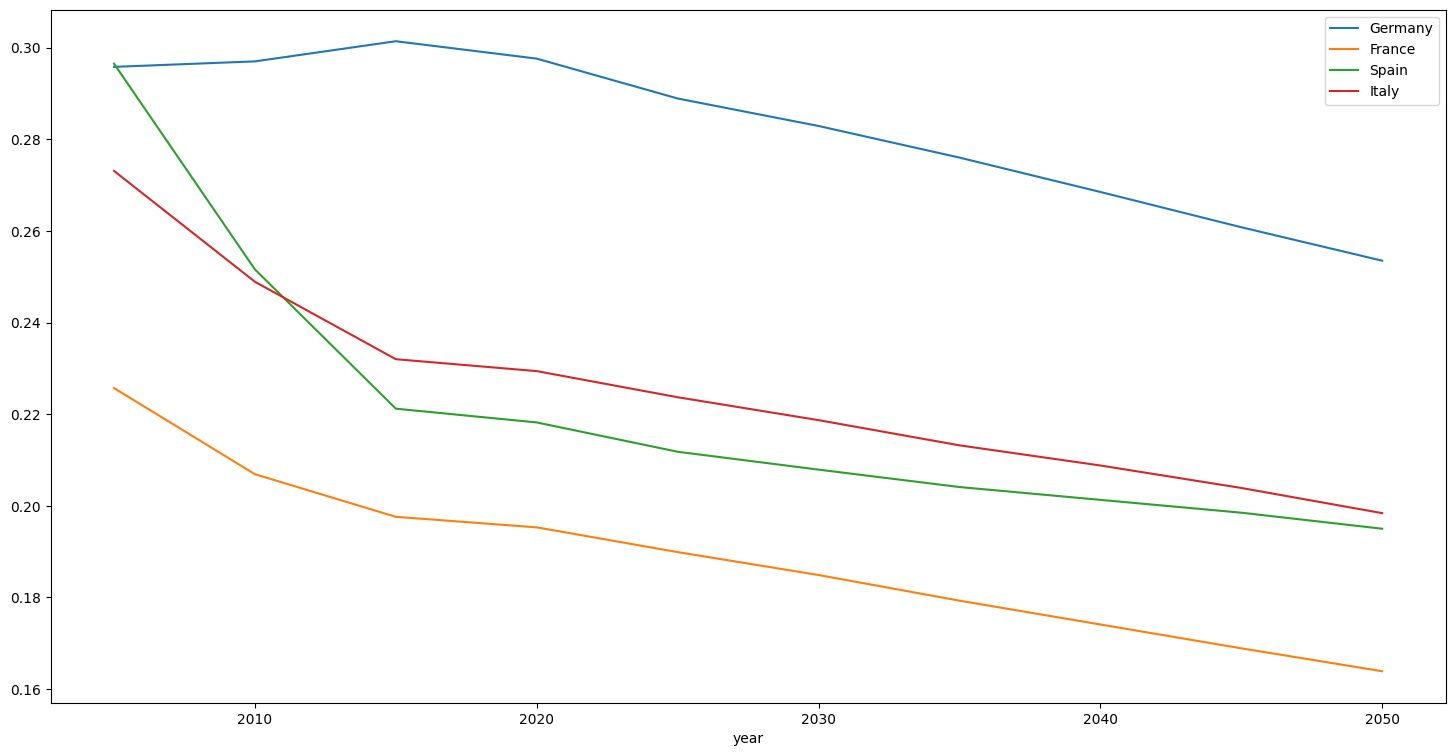

In [16]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    ssp.industry_va_PerUnit[:, country].plot(ax=ax, label=country)

ax.legend()
plt.show()

### Join gdp and indutry_va data using already used df gdp_growth_calc

here the dataFrame gdp_growth_calc is used, because it contains all years (yearly steps) from 1990 to 2060, and also contains the calculated gdp in Bn. USD.
So a new df called industry_va is created with columns of gdp_Bn.USD, industry_va_MioEUR and industry_va_PerUnit.

In [17]:
gdp_growth_calc = gdp_growth_calc.join(industry_va_hist, how="outer")
gdp_growth_calc = gdp_growth_calc.join(ssp, how="outer")
#gdp_growth_calc.loc[2025]

In [18]:
# only keep selected columns
industry_va = gdp_growth_calc[["gdp_Bn.USD", "industry_va_MioEUR", "industry_va_PerUnit"]]

# also multiply by 0.85 to convert USD to EUR
industry_va["gdp_X_industry_va_PerUnit_MrdEUR"] = industry_va["gdp_Bn.USD"] * industry_va["industry_va_PerUnit"] * 0.85
industry_va["industry_va_MrdEUR"] = industry_va.industry_va_MioEUR/1e3

# exporting the csv for comparison
industry_va.to_csv("Data - raw/prepared_data/industry_va_comparison.csv")
industry_va.loc[2025]

,gdp_Bn.USD,industry_va_MioEUR,industry_va_PerUnit,gdp_X_industry_va_PerUnit_MrdEUR,industry_va_MrdEUR
country,,,,,
Austria,579.085450,201073.9,0.2710,133.392333,201.0739
Belgium,755.644087,191184.2,0.2118,136.038605,191.1842
Bulgaria,226.296846,37454.8,0.2567,49.376840,37.4548
Croatia,172.376247,27051.1,0.2385,34.944975,27.0511
Czechia,533.278533,166805.2,0.3511,159.148979,166.8052
Denmark,452.540153,178831.2,0.2141,82.355520,178.8312
Estonia,58.359359,12700.0,0.2446,12.133494,12.7000
Finland,316.437958,103150.0,0.2556,68.749311,103.1500
France,3767.371630,782403.7,0.1899,608.110292,782.4037


## Prepare energy intensity --> energy_intensity

In [19]:
energy_intensity = pd.read_csv("Data - raw/energy_intensity_1990_2024.csv")

# selecting only the wanted columns and renaming name
energy_intensity = energy_intensity[["Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
energy_intensity= energy_intensity.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    #"geo": "country_code",
    "OBS_VALUE": "energy_intensity_KGOE_per_EUR_PPS",
})  

# only having the defined
energy_intensity = energy_intensity.loc[energy_intensity.country.isin(countries)]

energy_intensity = energy_intensity.set_index(["year", "country"])


energy_intensity#.loc[2024]

,,energy_intensity_KGOE_per_EUR_PPS
year,country,
1995,Austria,173.77
1996,Austria,176.43
1997,Austria,171.07
1998,Austria,166.71
1999,Austria,159.56
...,...,...
2020,Slovakia,133.50
2021,Slovakia,133.59
2022,Slovakia,119.40


## Prepare share of energy intensive industries --> eii_share

In [20]:
# C: Manufacturing,  
# C17: Paper, 
# C20: chemicals, 
# C23: non-metallic mineral products (cement etc.), 
# C24: basic metals (steel & aluminium etc.)

# The values here are gross value added in current pice, Mio. EUR

eii_calc = pd.read_csv("Data - raw/energy_intensive_industries_share_1990_2025.csv")

# selecting only the wanted columns and renaming name
eii_calc = eii_calc[["Geopolitical entity (reporting)", "TIME_PERIOD", "nace_r2", "OBS_VALUE"]]

eii_calc= eii_calc.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
})  

# only consider defined countries
eii_calc = eii_calc.loc[eii_calc.country.isin(countries)]

# pivoting the table to have a column for each measure!
eii_calc = eii_calc.reset_index().pivot(
    index=['year', 'country'],
    columns='nace_r2',
    values='OBS_VALUE'
)

# Filtering 2025 out, because a lot of values are missing!
eii_calc = eii_calc[eii_calc.index.get_level_values('year') != 2025]

# Missing Values: Norway, sweden, Ireland, Luxembourg --> zero!
#eii_calc[eii_calc.index.get_level_values('country').isin(["Norway", "Sweden", "Ireland", "Luxembourg"])].fillna(0)

# share of energy intensive industries (eei): forward filling of data in the middle of time period 
eii_calc[["C17", "C20", "C23", "C24"]] = (
    eii_calc.groupby(level="country")[["C17", "C20", "C23", "C24"]]
    .ffill() # use last available value to fill the data in the middle of time series
)

eii_calc = eii_calc.fillna(0)

# calculating the sum of energy_intensive_industries
eii_calc["C_X-sum"] = eii_calc["C17"] + eii_calc["C20"] + eii_calc["C23"] + eii_calc["C24"]
eii_calc["eii_share_Percent"] = 100 * eii_calc["C_X-sum"] / eii_calc["C"]

# only saving the eii_calc in a new df
eii_share = eii_calc[["eii_share_Percent"]]


#eii_share#.isnull().sum()
eii_calc

nace_r2               C     C17      C20     C23     C24  C_X-sum  \
year country                                                        
1990 Denmark    16186.9   443.8    871.6   767.2   399.5   2482.1   
     Finland    21733.0  2848.6   1217.3  1052.0   929.5   6047.4   
     France    158728.6     0.0   9407.3     0.0     0.0   9407.3   
     Norway      9728.5     0.0    787.7   405.5   825.8   2019.0   
1991 Denmark    16450.2   503.4    879.1   727.8   420.4   2530.7   
...                 ...     ...      ...     ...     ...      ...   
2024 Romania    46665.9   577.6   1008.6  2157.1   749.6   4492.9   
     Slovakia   21260.2   471.1    515.3   819.1  1008.6   2814.1   
     Slovenia   13056.9   222.7    530.4   444.6   516.9   1714.6   
     Spain     172896.0  4780.0  10825.0  8351.0  5237.0  29193.0   
     Sweden     72569.9  3472.0      0.0  1431.2  2804.9   7708.1   

nace_r2        eii_share_Percent  
year country                      
1990 Denmark           15.334005  
     Finland           27.825887  
     France             5.926657  
     Norway            20.753456  
1991 Denmark           15.384007  
...                          ...  
2024 Romania            9.627801  
     Slovakia          13.236470  
     Slovenia          13.131754  
     Spain             16.884717  
     Sweden            10.621621  

[802 rows x 7 columns]

## Prepare urbanization Rate

# Prepare Targets

## Preparing the demand data --> demand

### Total

In [21]:
demand_tot = pd.read_csv("Data - raw/Y-Electricity_demand_total_1990-2024.csv")

demand_tot = demand_tot[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
demand_tot = demand_tot.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "demand_tot_TWh"
})

demand_tot = demand_tot.loc[demand_tot.country.isin(countries)] 

demand_tot = demand_tot.set_index(["year", "country"])
demand_tot = demand_tot / 1e3   # GWh --> TWh

demand_tot

,,demand_tot_TWh
year,country,
1990,Austria,42.767
1991,Austria,44.818
1992,Austria,44.338
1993,Austria,44.958
1994,Austria,45.605
...,...,...
2020,Slovakia,23.813
2021,Slovakia,25.549
2022,Slovakia,22.870


### transport

In [22]:
demand_tra = pd.read_csv("Data - raw/Y-Electricity_demand_transport_1990-2024.csv")

demand_tra = demand_tra[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
demand_tra = demand_tra.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "demand_tra_TWh"
})

demand_tra = demand_tra.loc[demand_tra.country.isin(countries)] 

demand_tra = demand_tra.set_index(["year", "country"])
demand_tra = demand_tra / 1e3   # GWh --> TWh

demand_tra

,,demand_tra_TWh
year,country,
1990,Austria,2.770
1991,Austria,3.162
1992,Austria,3.243
1993,Austria,3.239
1994,Austria,3.239
...,...,...
2020,Slovakia,0.505
2021,Slovakia,0.586
2022,Slovakia,0.667


### industry

In [23]:
demand_ind = pd.read_csv("Data - raw/Y-Electricity_demand_industry_1990-2024.csv")

demand_ind = demand_ind[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
demand_ind = demand_ind.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "demand_ind_TWh"
})

demand_ind = demand_ind.loc[demand_ind.country.isin(countries)] 

demand_ind = demand_ind.set_index(["year", "country"])
demand_ind = demand_ind / 1e3   # GWh --> TWh

demand_ind

,,demand_ind_TWh
year,country,
1990,Austria,17.980
1991,Austria,18.275
1992,Austria,17.831
1993,Austria,17.657
1994,Austria,18.371
...,...,...
2020,Slovakia,10.501
2021,Slovakia,11.608
2022,Slovakia,9.925


### Other Sectors (Gebäude)

In [24]:
# other_sectors (Gebäude)
demand_oth = pd.read_csv("Data - raw/Y-Electricity_demand_other_sectors_1990-2024.csv")

demand_oth = demand_oth[["TIME_PERIOD", "Geopolitical entity (reporting)", "OBS_VALUE"]]
demand_oth = demand_oth.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "demand_oth_TWh"
})

demand_oth = demand_oth.loc[demand_oth.country.isin(countries)] 

demand_oth = demand_oth.set_index(["year", "country"])
demand_oth = demand_oth / 1e3   # GWh --> TWh

demand_oth

,,demand_oth_TWh
year,country,
1990,Austria,22.017
1991,Austria,23.381
1992,Austria,23.264
1993,Austria,24.062
1994,Austria,23.995
...,...,...
2020,Slovakia,12.807
2021,Slovakia,13.355
2022,Slovakia,12.278


### Merging All demand data together

In [25]:
demand = demand_ind.join(demand_tra)
demand = demand.join(demand_oth)
demand = demand.join(demand_tot)
demand

,,demand_ind_TWh,demand_tra_TWh,demand_oth_TWh,demand_tot_TWh
year,country,,,,
1990,Austria,17.980,2.770,22.017,42.767
1991,Austria,18.275,3.162,23.381,44.818
1992,Austria,17.831,3.243,23.264,44.338
1993,Austria,17.657,3.239,24.062,44.958
1994,Austria,18.371,3.239,23.995,45.605
...,...,...,...,...,...
2020,Slovakia,10.501,0.505,12.807,23.813
2021,Slovakia,11.608,0.586,13.355,25.549
2022,Slovakia,9.925,0.667,12.278,22.870


# Creating Panel_data.csv

## Creating the panel data --> panel

In [26]:
# first joining all input parameters
panel = pop.join(gdp_per_capita)
panel = panel.join(gdp_growth)
panel = panel.join(hdd_cdd)
panel = panel.join(industry_va_hist)
panel = panel.join(energy_intensity)
panel = panel.join(eii_share)
#panel = panel.join(co2)


# then joining the target variables
panel = panel.join(demand)
panel = panel.sort_index()
panel

population_Mio  gdp_per_capita_USD  gdp_growth_rate_Percent  \
year country                                                                 
1990 Austria         7.644818         43177.35409                 3.299014   
     Belgium         9.947782         41647.81322                 3.299014   
     Bulgaria        8.767308                 NaN                 3.299014   
     Croatia         4.772556                 NaN                 3.299014   
     Czechia        10.362102         30937.81727                 3.299014   
...                       ...                 ...                      ...   
2060 Romania        16.333523         72256.62000                 1.007720   
     Slovakia        4.850265         69326.40000                 0.888031   
     Slovenia        2.047613         81846.32000                 1.617258   
     Spain          53.468132         75910.47000                 1.517263   
     Sweden         11.667100        106829.70000                 1.537496   

               hdd_DegreesC  cdd_DegreesC  industry_va_MioEUR  \
year country                                                    
1990 Austria    3647.948556     25.646842                 NaN   
     Belgium    2276.951920     46.296132                 NaN   
     Bulgaria   2416.963240    129.481837                 NaN   
     Croatia    1947.345518    106.441446                 NaN   
     Czechia    3008.033596     32.228258                 NaN   
...                     ...           ...                 ...   
2060 Romania    2543.820865    360.308119                 NaN   
     Slovakia   2855.311013    182.376955                 NaN   
     Slovenia   2240.830881    195.764920                 NaN   
     Spain      1176.424436    363.398075                 NaN   
     Sweden     4526.402532     11.973012                 NaN   

               energy_intensity_KGOE_per_EUR_PPS  eii_share_Percent  \
year country                                                          
1990 Austria                                 NaN                NaN   
     Belgium                                 NaN                NaN   
     Bulgaria                                NaN                NaN   
     Croatia                                 NaN                NaN   
     Czechia                                 NaN                NaN   
...                                          ...                ...   
2060 Romania                                 NaN                NaN   
     Slovakia                                NaN                NaN   
     Slovenia                                NaN                NaN   
     Spain                                   NaN                NaN   
     Sweden                                  NaN                NaN   

               demand_ind_TWh  demand_tra_TWh  demand_oth_TWh  demand_tot_TWh  
year country                                                                   
1990 Austria           17.980           2.770          22.017          42.767  
     Belgium           30.523           1.249          26.212          57.984  
     Bulgaria          18.552           1.305          15.415          35.272  
     Croatia            5.984           0.369           6.950          13.303  
     Czechia           26.922           3.167          18.088          48.177  
...                       ...             ...             ...             ...  
2060 Romania              NaN             NaN             NaN             NaN  
     Slovakia             NaN             NaN             NaN             NaN  
     Slovenia             NaN             NaN             NaN             NaN  
     Spain                NaN             NaN             NaN             NaN  
     Sweden               NaN             NaN             NaN             NaN  

[1222 rows x 12 columns]

In [27]:
# check if columns have missing values
# it is normal that demands has missing values, because they are the Targets to be forecasted!

print("\nBefore Handling Missing Values:\n")
for column in panel.columns:
    print(f"{column}:\t\t\t\t{panel[column].isna().sum()} missing values!")


Before Handling Missing Values:

population_Mio:				0 missing values!
gdp_per_capita_USD:				33 missing values!
gdp_growth_rate_Percent:				0 missing values!
hdd_DegreesC:				0 missing values!
cdd_DegreesC:				0 missing values!
industry_va_MioEUR:				395 missing values!
energy_intensity_KGOE_per_EUR_PPS:				442 missing values!
eii_share_Percent:				420 missing values!
demand_ind_TWh:				312 missing values!
demand_tra_TWh:				312 missing values!
demand_oth_TWh:				312 missing values!
demand_tot_TWh:				312 missing values!


## Handling missing values

In [28]:
panel = panel.sort_index()

# gdp_per_capita: filling backward for each country
panel["gdp_per_capita_USD"] = (
    panel.groupby(level="country")["gdp_per_capita_USD"]
    .bfill()
)

"""# industry value added (va): filling backward for each country
panel["industry_va_MioEUR"] = (
    panel.groupby(level="country")["industry_va_MioEUR"]
    #.transform(lambda s: s.interpolate(method="linear", limit_direction="backward"))
    .bfill()
)"""

# industry value added (va): projection of values using a log-linear trend for 
panel["industry_va_MioEUR"] = (
    panel.groupby(level="country")["industry_va_MioEUR"]
    .transform(fill_log_linear)
)

"""# energy intensity: filling backward for each country
panel["energy_intensity_KGOE_per_EUR_PPS"] = (
    panel.groupby(level="country")["energy_intensity_KGOE_per_EUR_PPS"]
    #.transform(lambda s: s.interpolate(method="linear", limit_direction="backward"))
    .bfill()
)"""

# energy intensity: projection of values using a log-linear trend for 
panel["energy_intensity_KGOE_per_EUR_PPS"] = (
    panel.groupby(level="country")["energy_intensity_KGOE_per_EUR_PPS"]
    .transform(fill_log_linear, 2024) # adjusting last_hist_year=2025, window=30
)

# share of energy intensive industries (eei): projection of values using a log-linear trend for 
panel["eii_share_Percent"] = (
    panel.groupby(level="country")["eii_share_Percent"]
    .transform(fill_log_linear, 2024, 20) # adjusting last_hist_year=24, window=25
)

panel#.loc[1990]

population_Mio  gdp_per_capita_USD  gdp_growth_rate_Percent  \
year country                                                                 
1990 Austria         7.644818         43177.35409                 3.299014   
     Belgium         9.947782         41647.81322                 3.299014   
     Bulgaria        8.767308         13688.68504                 3.299014   
     Croatia         4.772556         17519.10144                 3.299014   
     Czechia        10.362102         30937.81727                 3.299014   
...                       ...                 ...                      ...   
2060 Romania        16.333523         72256.62000                 1.007720   
     Slovakia        4.850265         69326.40000                 0.888031   
     Slovenia        2.047613         81846.32000                 1.617258   
     Spain          53.468132         75910.47000                 1.517263   
     Sweden         11.667100        106829.70000                 1.537496   

               hdd_DegreesC  cdd_DegreesC  industry_va_MioEUR  \
year country                                                    
1990 Austria    3647.948556     25.646842        7.664733e+04   
     Belgium    2276.951920     46.296132        8.833031e+04   
     Bulgaria   2416.963240    129.481837        3.161450e+03   
     Croatia    1947.345518    106.441446        6.163844e+03   
     Czechia    3008.033596     32.228258        2.050151e+04   
...                     ...           ...                 ...   
2060 Romania    2543.820865    360.308119        6.022041e+05   
     Slovakia   2855.311013    182.376955        2.641535e+05   
     Slovenia   2240.830881    195.764920        1.825112e+05   
     Spain      1176.424436    363.398075        1.492541e+06   
     Sweden     4526.402532     11.973012        3.976636e+05   

               energy_intensity_KGOE_per_EUR_PPS  eii_share_Percent  \
year country                                                          
1990 Austria                          192.027394          21.727865   
     Belgium                          355.189131          32.904307   
     Bulgaria                         527.373715          17.535800   
     Croatia                          286.260082          13.400261   
     Czechia                          406.660885          32.214568   
...                                          ...                ...   
2060 Romania                           17.462966           7.582405   
     Slovakia                          32.290454           4.521986   
     Slovenia                          27.457074           9.553269   
     Spain                             24.076714          13.722746   
     Sweden                            33.406106           9.295892   

               demand_ind_TWh  demand_tra_TWh  demand_oth_TWh  demand_tot_TWh  
year country                                                                   
1990 Austria           17.980           2.770          22.017          42.767  
     Belgium           30.523           1.249          26.212          57.984  
     Bulgaria          18.552           1.305          15.415          35.272  
     Croatia            5.984           0.369           6.950          13.303  
     Czechia           26.922           3.167          18.088          48.177  
...                       ...             ...             ...             ...  
2060 Romania              NaN             NaN             NaN             NaN  
     Slovakia             NaN             NaN             NaN             NaN  
     Slovenia             NaN             NaN             NaN             NaN  
     Spain                NaN             NaN             NaN             NaN  
     Sweden               NaN             NaN             NaN             NaN  

[1222 rows x 12 columns]

In [29]:
print("\nAfter Handling Missing Values:\n")
# check if columns have missing values
# it is normal that demands has missing values, because they are the Targets to be forecasted!
for column in panel.columns:
    print(f"{column}:\t\t\t\t{panel[column].isna().sum()} missing values!")


After Handling Missing Values:

population_Mio:				0 missing values!
gdp_per_capita_USD:				0 missing values!
gdp_growth_rate_Percent:				0 missing values!
hdd_DegreesC:				0 missing values!
cdd_DegreesC:				0 missing values!
industry_va_MioEUR:				0 missing values!
energy_intensity_KGOE_per_EUR_PPS:				0 missing values!
eii_share_Percent:				0 missing values!
demand_ind_TWh:				312 missing values!
demand_tra_TWh:				312 missing values!
demand_oth_TWh:				312 missing values!
demand_tot_TWh:				312 missing values!


In [30]:
panel[panel.eii_share_Percent.isnull()].tail(20)

,,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,industry_va_MioEUR,energy_intensity_KGOE_per_EUR_PPS,eii_share_Percent,demand_ind_TWh,demand_tra_TWh,demand_oth_TWh,demand_tot_TWh
year,country,,,,,,,,,,,,


## Exporting the prepared panel Data

In [31]:
panel.to_csv("Data - raw/prepared_data/panel.csv")

# Exploring and Visualization tests

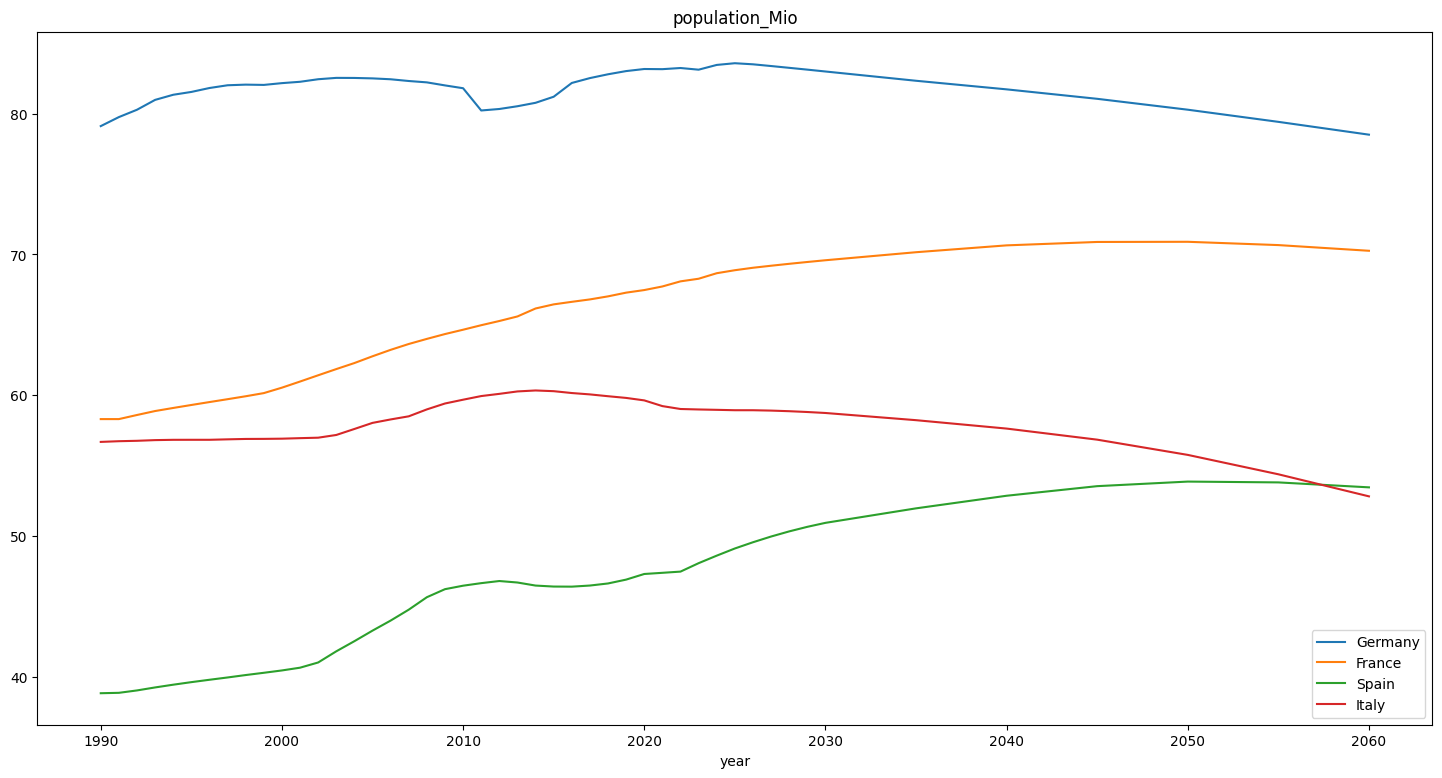

In [32]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.population_Mio[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("population_Mio")
plt.show()

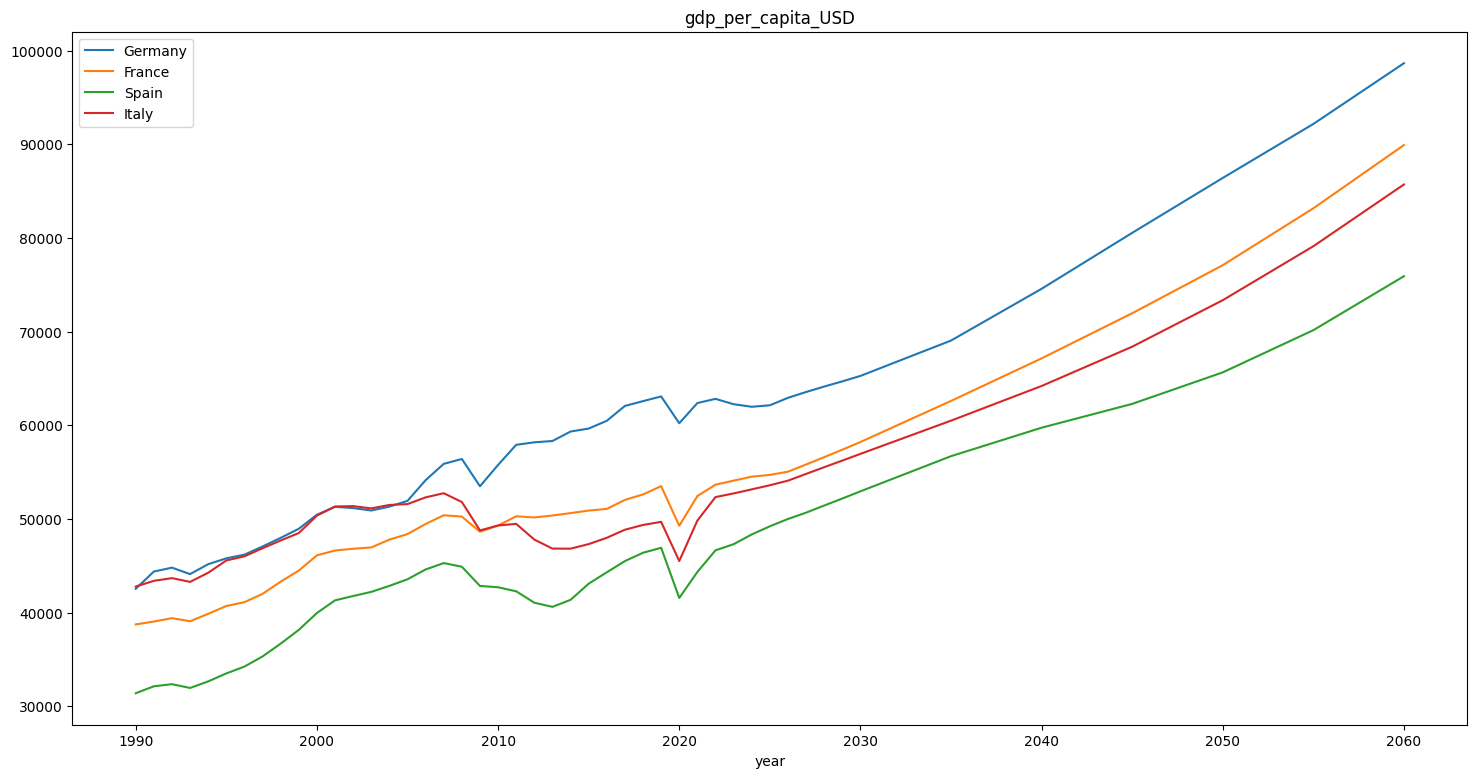

In [33]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.gdp_per_capita_USD[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("gdp_per_capita_USD")
plt.show()

In [34]:
"""fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy", "Sweden", "Czechia"]:
    if country == "Germany including former GDR":
        continue
    panel.gdp_growth_rate_Percent[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("gdp_growth_rate_Percent")
plt.show()"""

'fig, ax = plt.subplots(figsize=(18, 9))\n\n#for country in countries:\nfor country in ["Germany", "France", "Spain", "Italy", "Sweden", "Czechia"]:\n    if country == "Germany including former GDR":\n        continue\n    panel.gdp_growth_rate_Percent[:, country].plot(ax=ax, label=country)\n\nax.legend()\nax.set_title("gdp_growth_rate_Percent")\nplt.show()'

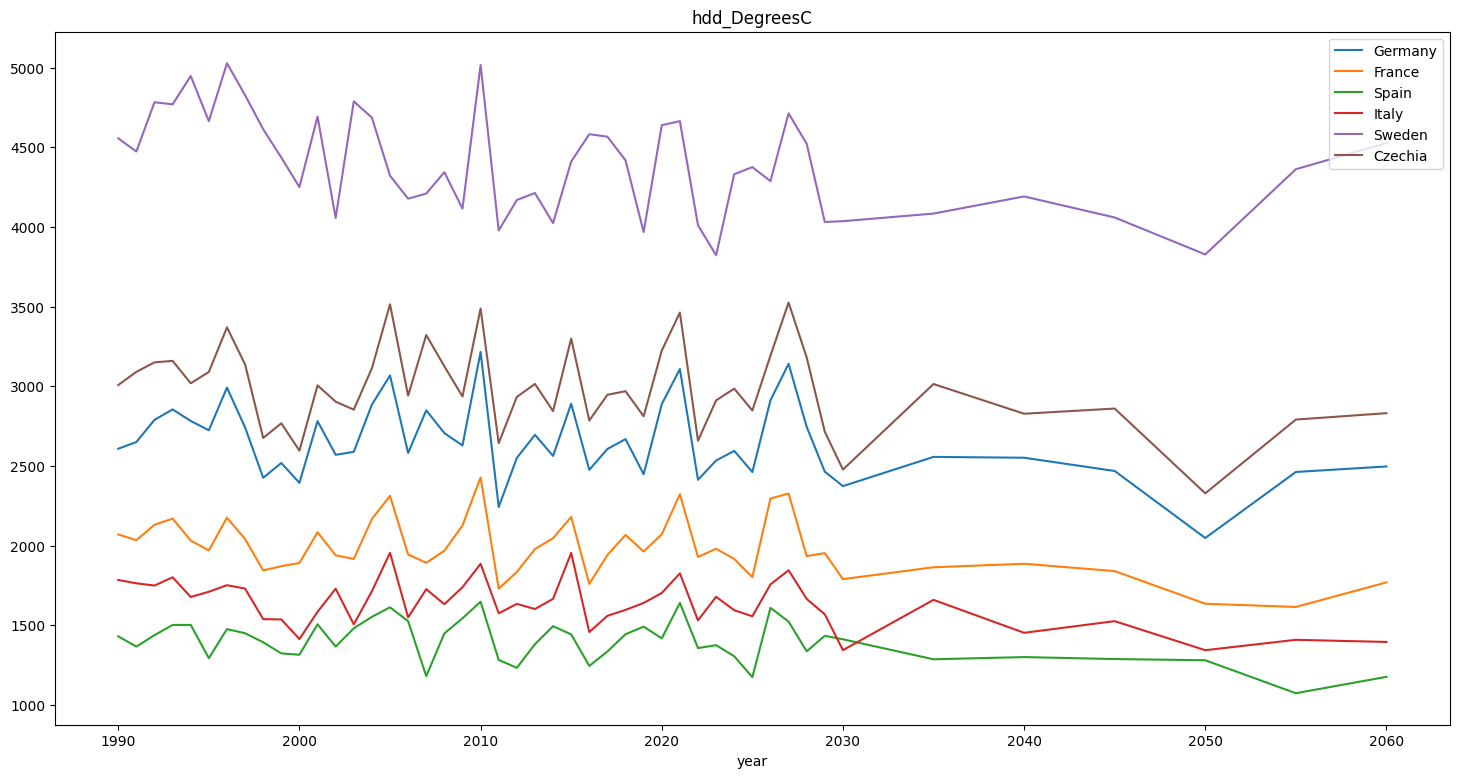

In [35]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy", "Sweden", "Czechia"]:
    if country == "Germany including former GDR":
        continue
    panel.hdd_DegreesC[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("hdd_DegreesC")
plt.show()

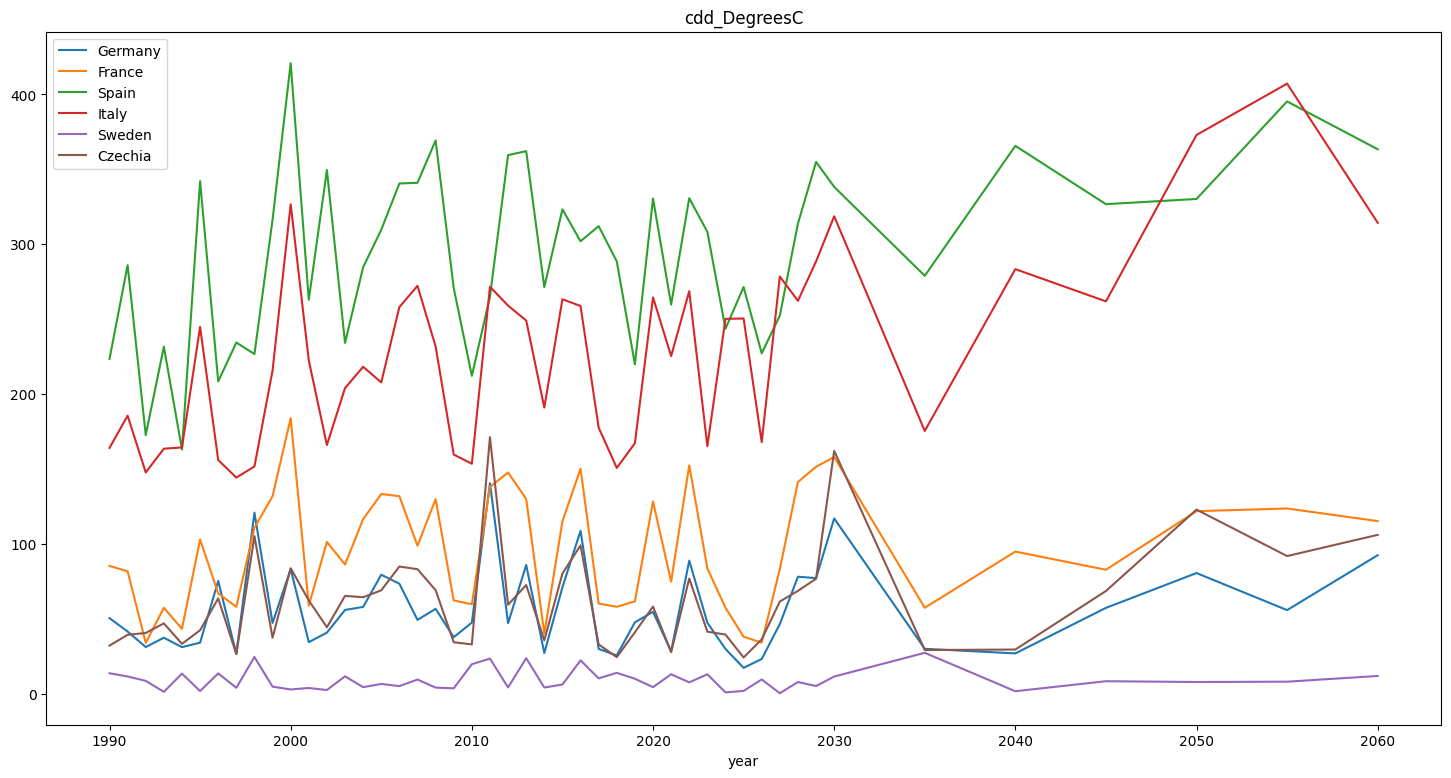

In [36]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy", "Sweden", "Czechia"]:
    if country == "Germany including former GDR":
        continue
    panel.cdd_DegreesC[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("cdd_DegreesC")
plt.show()

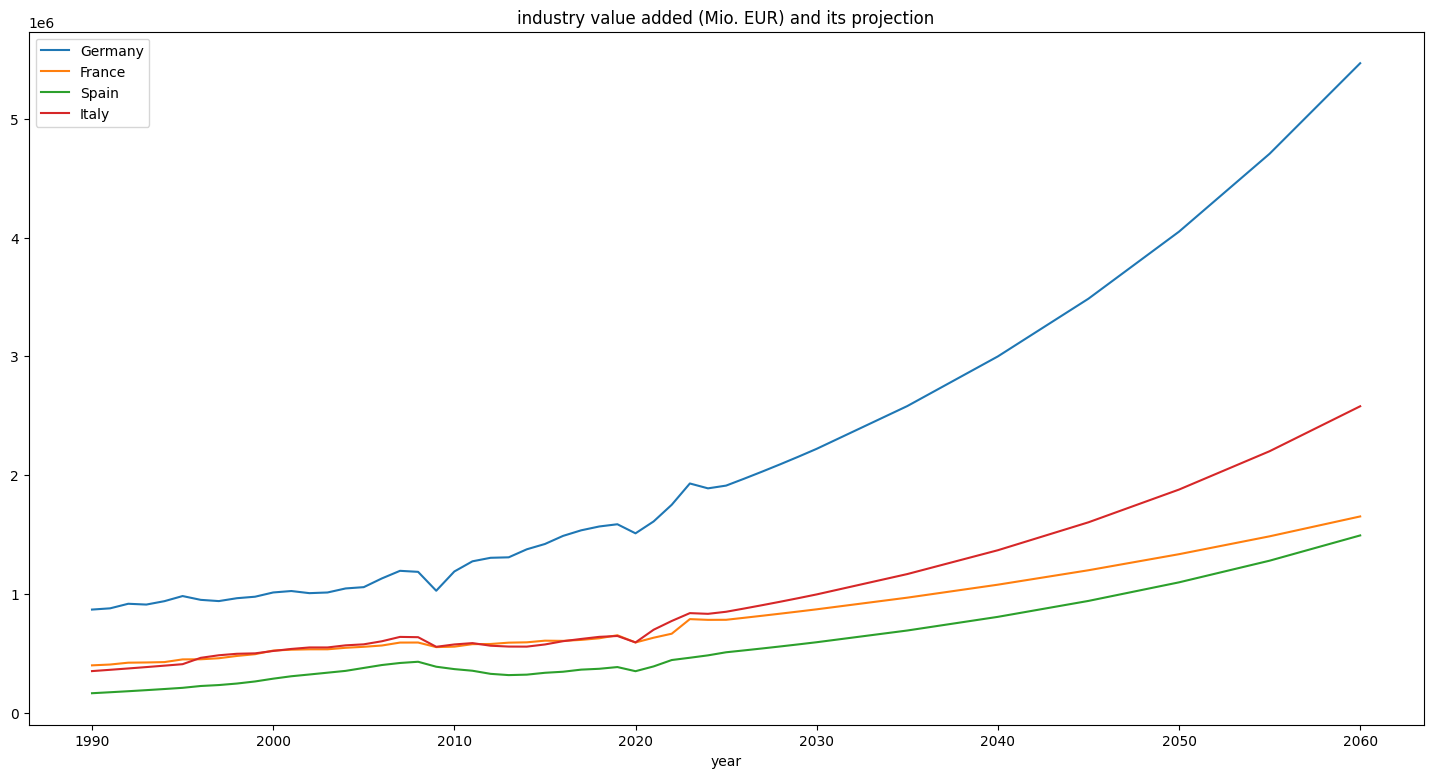

In [37]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.industry_va_MioEUR[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("industry value added (Mio. EUR) and its projection")
plt.show()

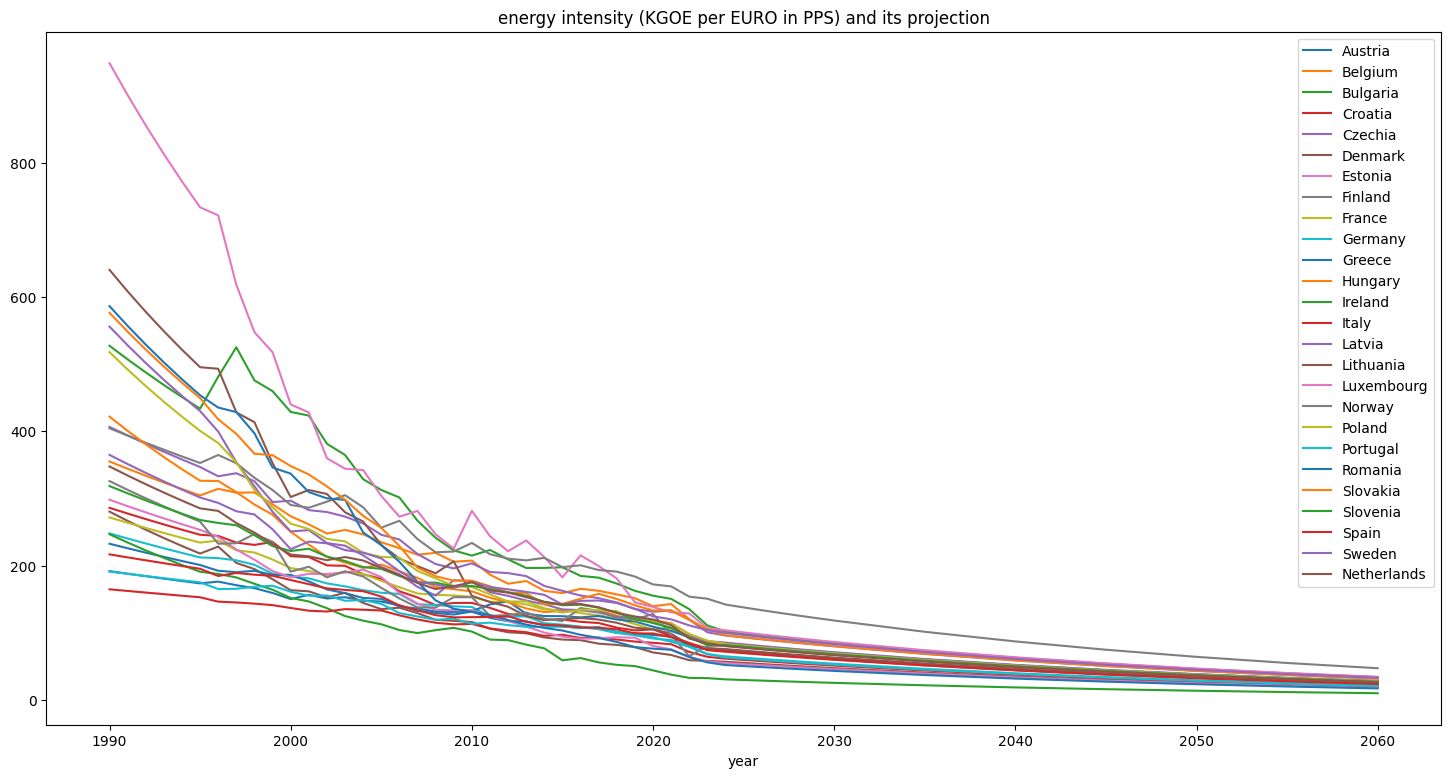

In [38]:
fig, ax = plt.subplots(figsize=(18, 9))

for country in countries:
#for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.energy_intensity_KGOE_per_EUR_PPS[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("energy intensity (KGOE per EURO in PPS) and its projection")
plt.show()

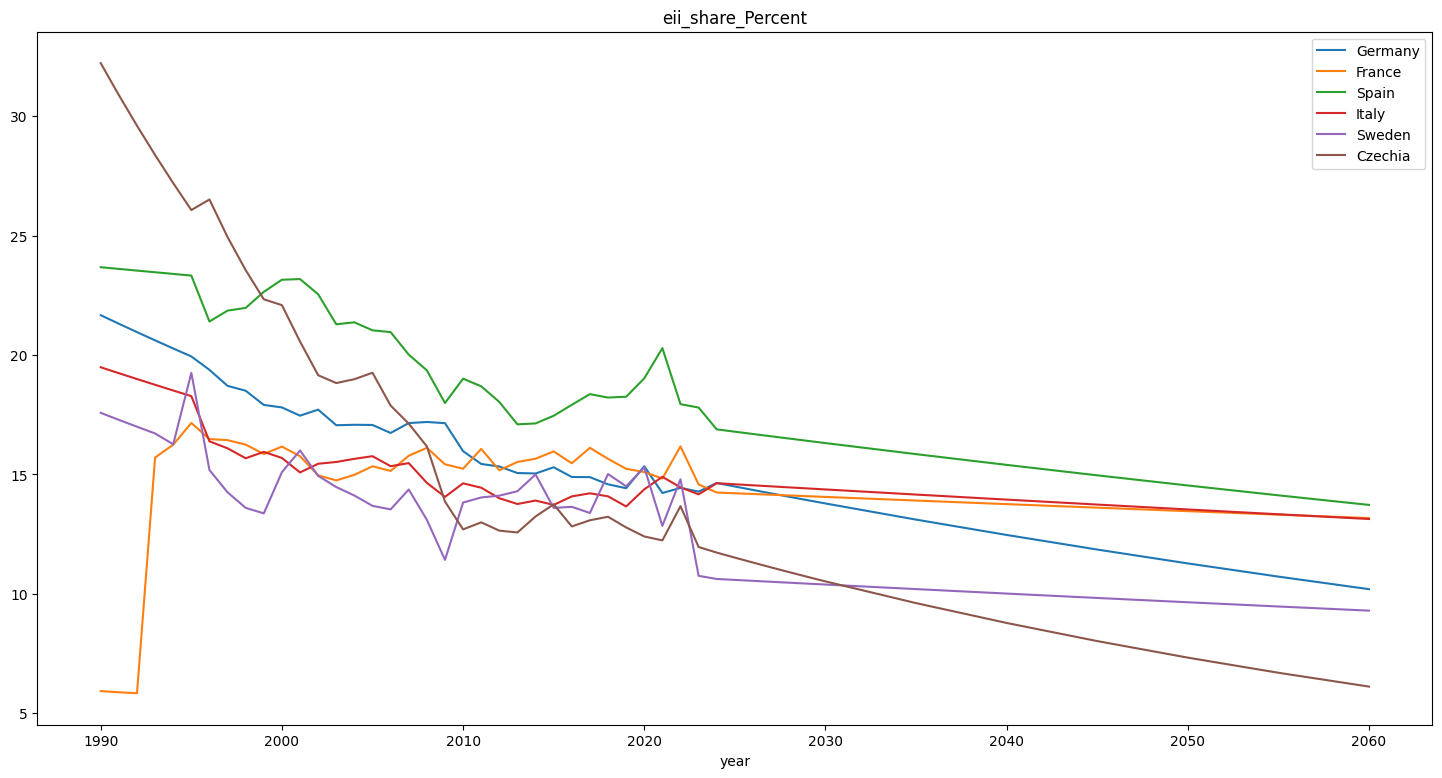

In [39]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy", "Sweden", "Czechia"]:
    if country == "Germany including former GDR":
        continue
    panel.eii_share_Percent[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("eii_share_Percent")
plt.show()

#######################

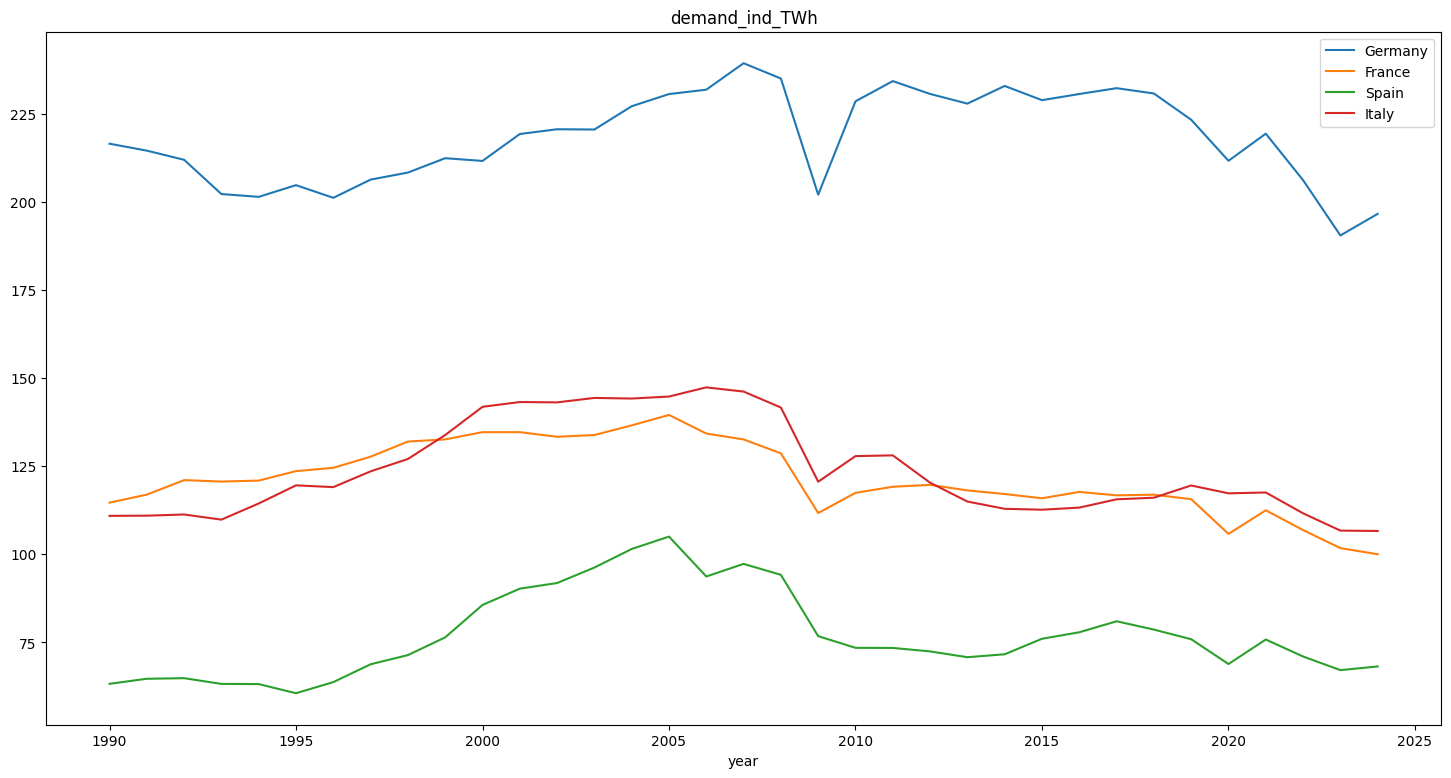

In [40]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.demand_ind_TWh[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_ind_TWh")
plt.show()

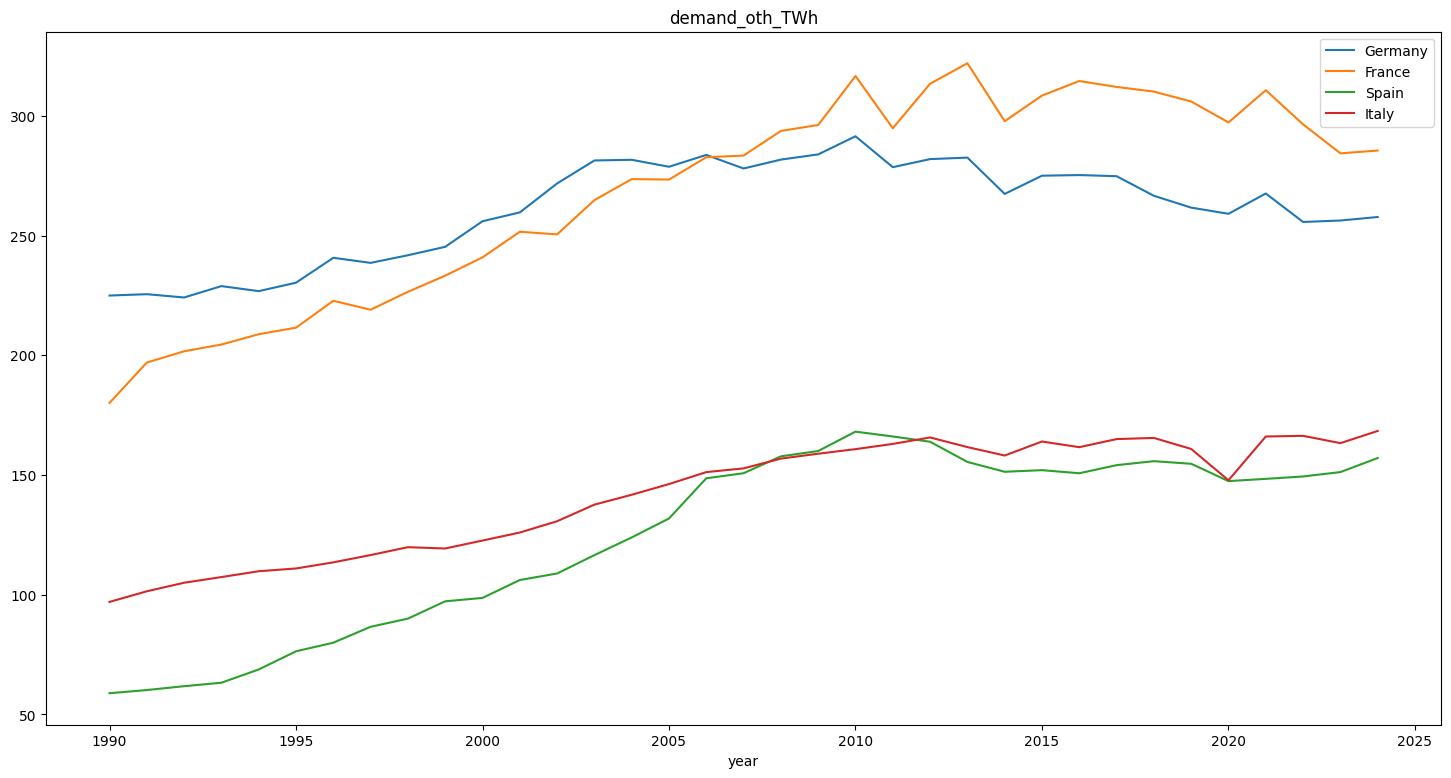

In [41]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.demand_oth_TWh[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_oth_TWh")
plt.show()

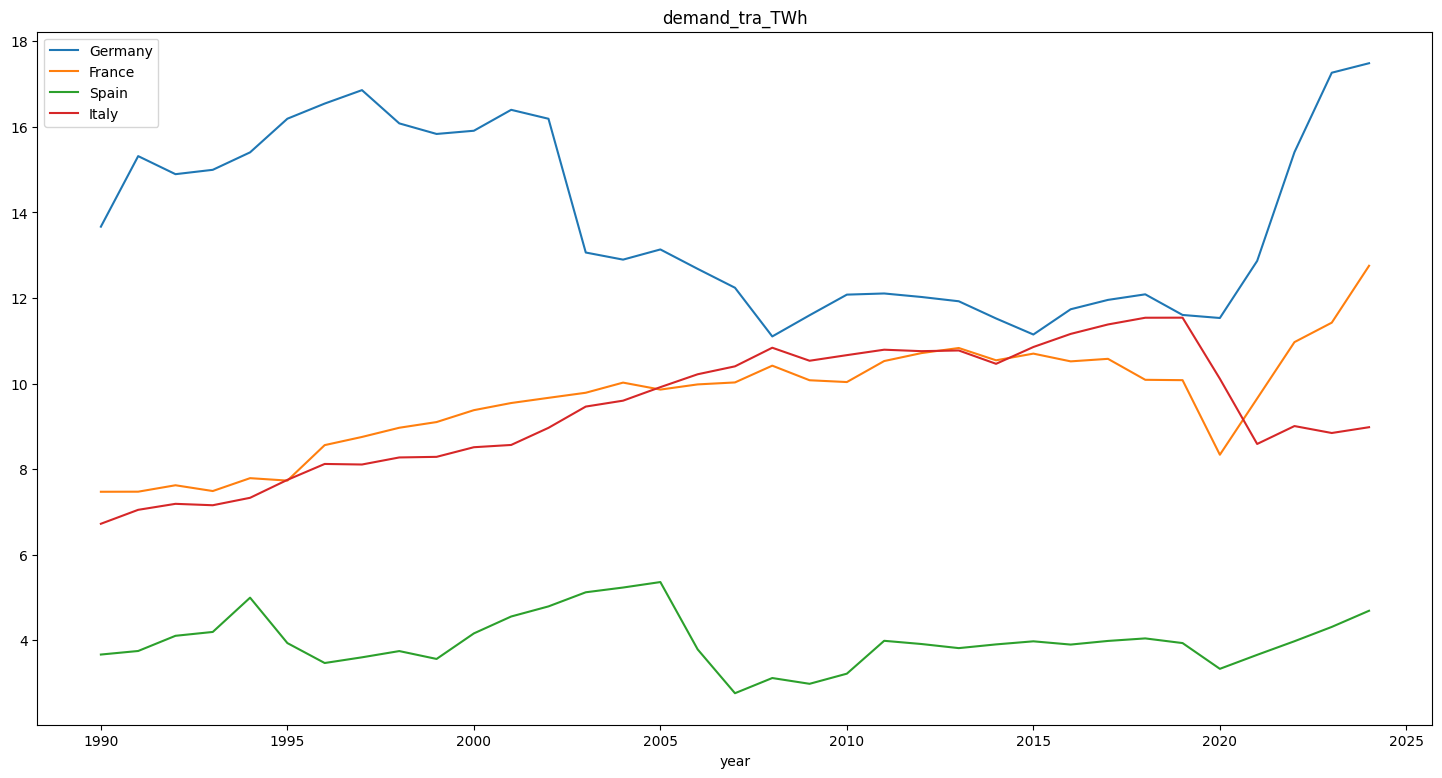

In [42]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.demand_tra_TWh[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_tra_TWh")
plt.show()

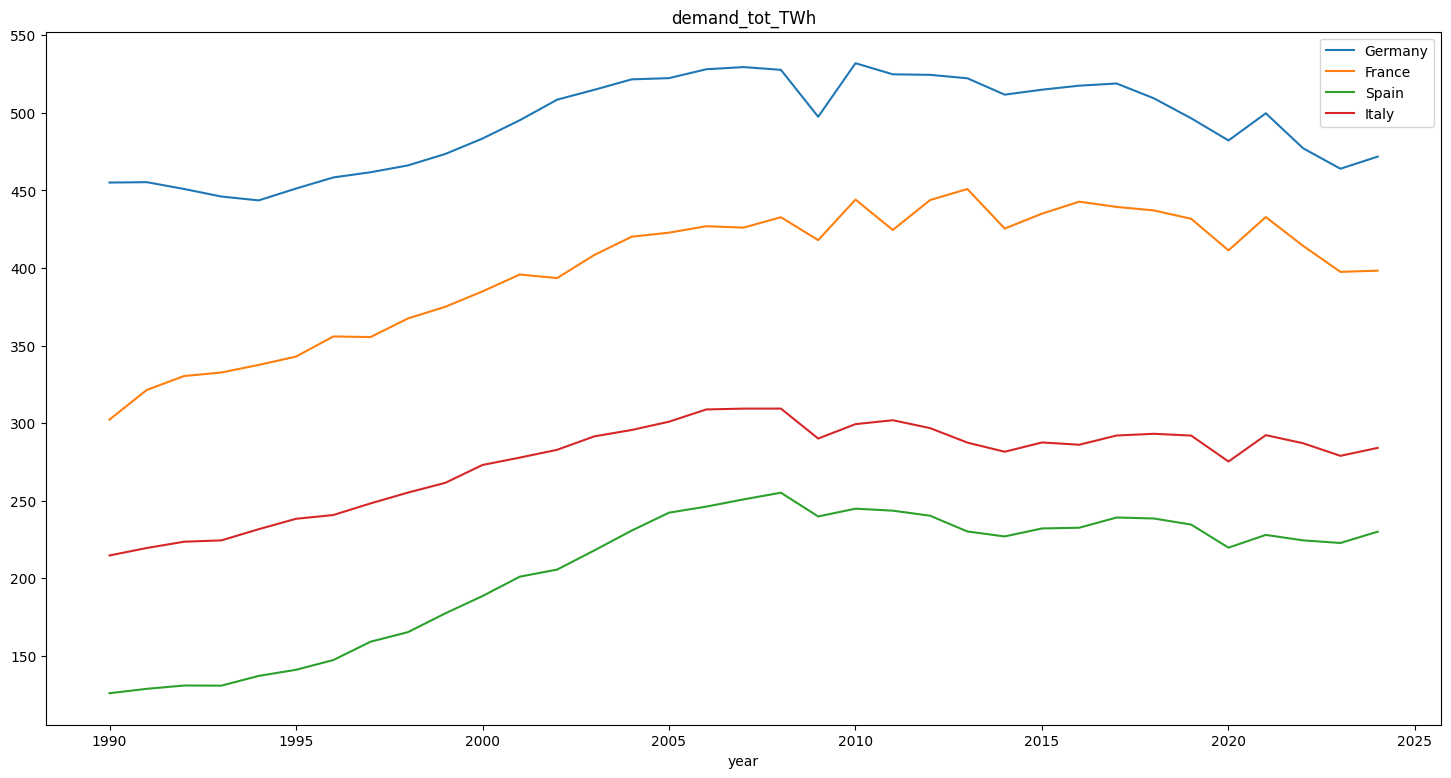

In [43]:
fig, ax = plt.subplots(figsize=(18, 9))

#for country in countries:
for country in ["Germany", "France", "Spain", "Italy"]:
    if country == "Germany including former GDR":
        continue
    panel.demand_tot_TWh[:, country].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_tot_TWh")
plt.show()

# Log-Transform the data

In [44]:
panel["ln_gdp_pc"] = np.log1p(panel['gdp_per_capita_USD'])
panel["ln_pop"] = np.log1p(panel['population_Mio'])
panel["ln_industry_gva"] = np.log1p(panel['industry_va_MioEUR'])
panel["ln_energy_intensity"] = np.log1p(panel['energy_intensity_KGOE_per_EUR_PPS'])
panel['ln_hdd'] = np.log1p(panel['hdd_DegreesC'])
panel['ln_cdd'] = np.log1p(panel['cdd_DegreesC'])

# ── Log-transform targets (only for historical rows with actual values) ───────
for target in ['demand_ind_TWh', 'demand_tra_TWh', 'demand_oth_TWh']:
    panel[f'ln_{target}'] = np.where(panel[target] > 0, np.log(panel[target]), np.nan)

panel.to_csv("Data - raw/prepared_data/panel_transformed.csv")

panel

population_Mio  gdp_per_capita_USD  gdp_growth_rate_Percent  \
year country                                                                 
1990 Austria         7.644818         43177.35409                 3.299014   
     Belgium         9.947782         41647.81322                 3.299014   
     Bulgaria        8.767308         13688.68504                 3.299014   
     Croatia         4.772556         17519.10144                 3.299014   
     Czechia        10.362102         30937.81727                 3.299014   
...                       ...                 ...                      ...   
2060 Romania        16.333523         72256.62000                 1.007720   
     Slovakia        4.850265         69326.40000                 0.888031   
     Slovenia        2.047613         81846.32000                 1.617258   
     Spain          53.468132         75910.47000                 1.517263   
     Sweden         11.667100        106829.70000                 1.537496   

               hdd_DegreesC  cdd_DegreesC  industry_va_MioEUR  \
year country                                                    
1990 Austria    3647.948556     25.646842        7.664733e+04   
     Belgium    2276.951920     46.296132        8.833031e+04   
     Bulgaria   2416.963240    129.481837        3.161450e+03   
     Croatia    1947.345518    106.441446        6.163844e+03   
     Czechia    3008.033596     32.228258        2.050151e+04   
...                     ...           ...                 ...   
2060 Romania    2543.820865    360.308119        6.022041e+05   
     Slovakia   2855.311013    182.376955        2.641535e+05   
     Slovenia   2240.830881    195.764920        1.825112e+05   
     Spain      1176.424436    363.398075        1.492541e+06   
     Sweden     4526.402532     11.973012        3.976636e+05   

               energy_intensity_KGOE_per_EUR_PPS  eii_share_Percent  \
year country                                                          
1990 Austria                          192.027394          21.727865   
     Belgium                          355.189131          32.904307   
     Bulgaria                         527.373715          17.535800   
     Croatia                          286.260082          13.400261   
     Czechia                          406.660885          32.214568   
...                                          ...                ...   
2060 Romania                           17.462966           7.582405   
     Slovakia                          32.290454           4.521986   
     Slovenia                          27.457074           9.553269   
     Spain                             24.076714          13.722746   
     Sweden                            33.406106           9.295892   

               demand_ind_TWh  demand_tra_TWh  ...  demand_tot_TWh  ln_gdp_pc  \
year country                                   ...                              
1990 Austria           17.980           2.770  ...          42.767  10.673095   
     Belgium           30.523           1.249  ...          57.984  10.637028   
     Bulgaria          18.552           1.305  ...          35.272   9.524398   
     Croatia            5.984           0.369  ...          13.303   9.771104   
     Czechia           26.922           3.167  ...          48.177  10.339767   
...                       ...             ...  ...             ...        ...   
2060 Romania              NaN             NaN  ...             NaN  11.187993   
     Slovakia             NaN             NaN  ...             NaN  11.146595   
     Slovenia             NaN             NaN  ...             NaN  11.312611   
     Spain                NaN             NaN  ...             NaN  11.237323   
     Sweden               NaN             NaN  ...             NaN  11.579001   

                 ln_pop  ln_industry_gva  ln_energy_intensity    ln_hdd  \
year country                                                              
1990 Austria   2.156960   

# Correlations

In [45]:
# calculating the correlations for each country!
COUNTRY = "Sweden"

corr_by_country = panel.groupby(level='country').corr()
corr = corr_by_country.loc[COUNTRY]

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_2895/1556514089.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f, ax = plt.subplots(figsize=(11, 9))


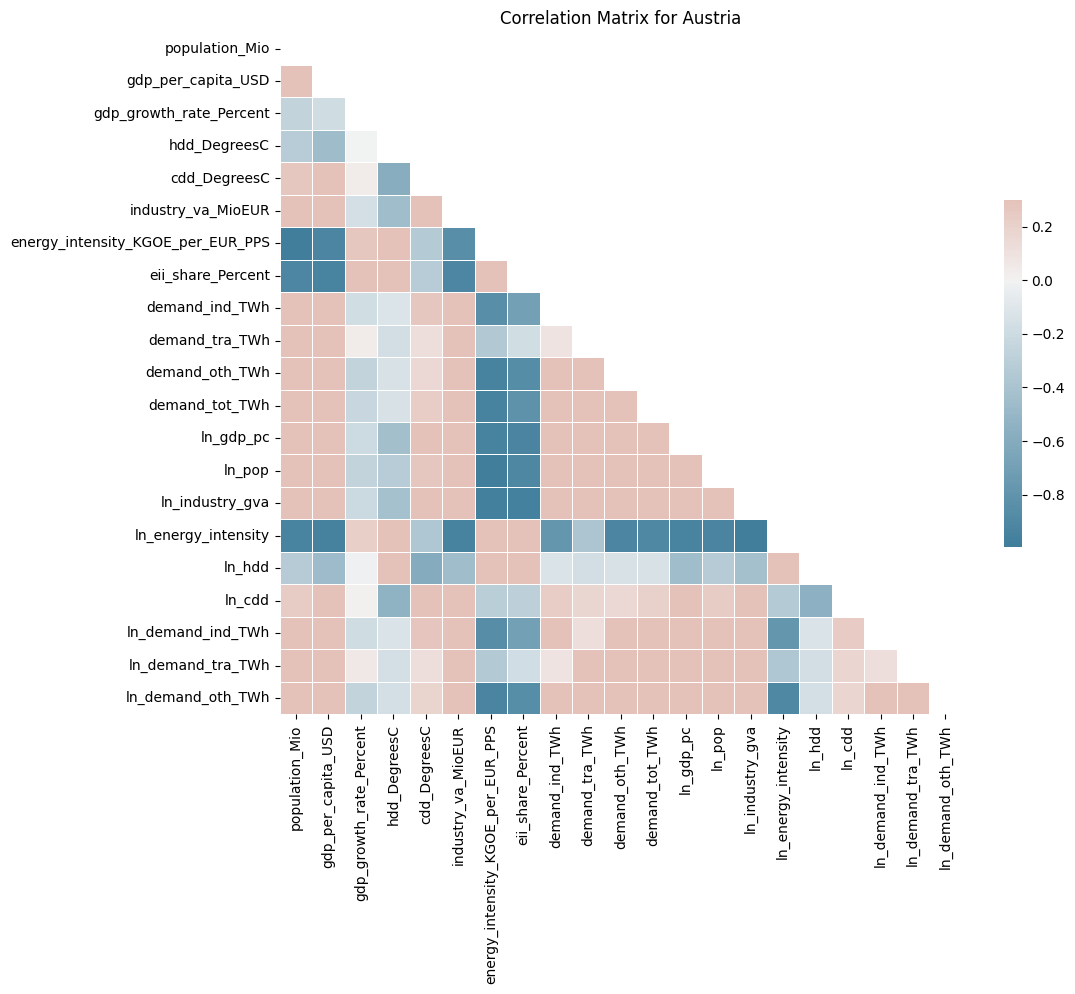

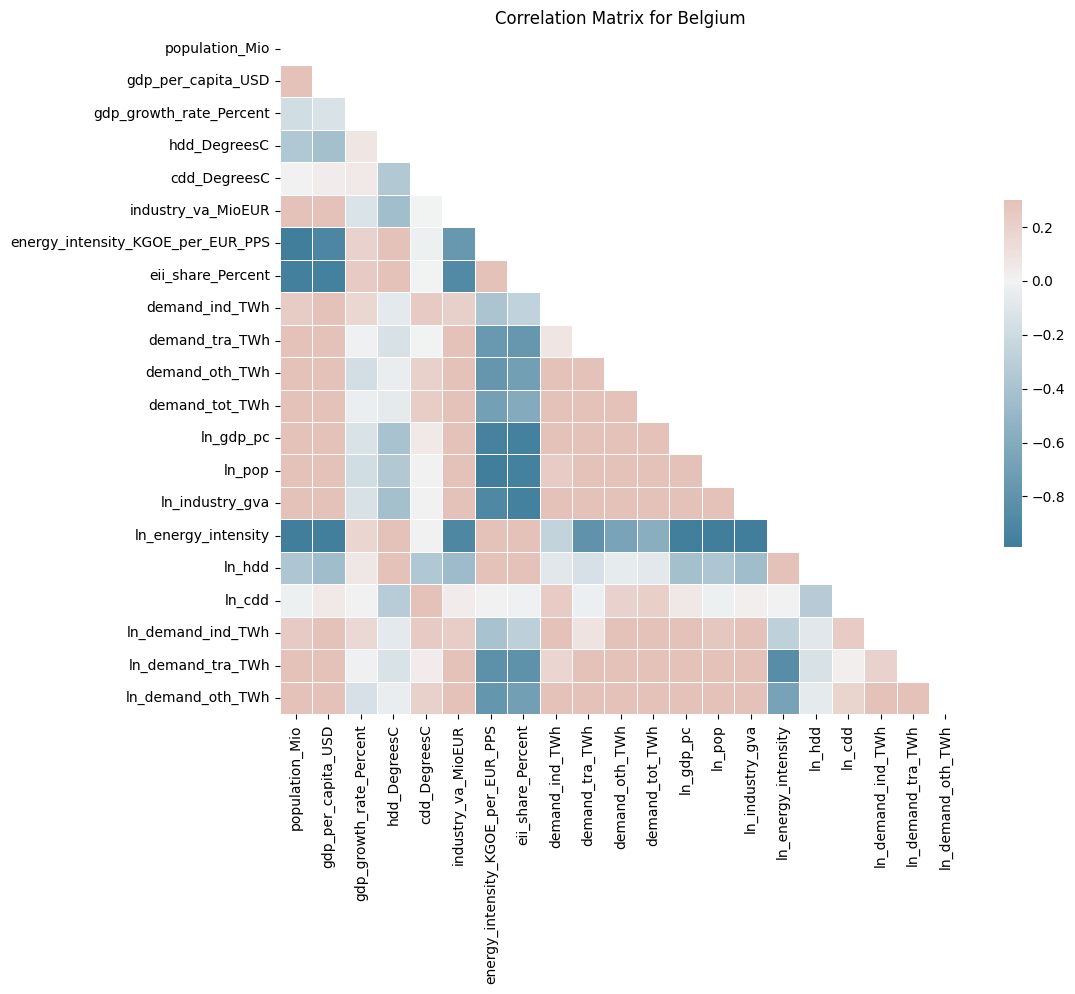

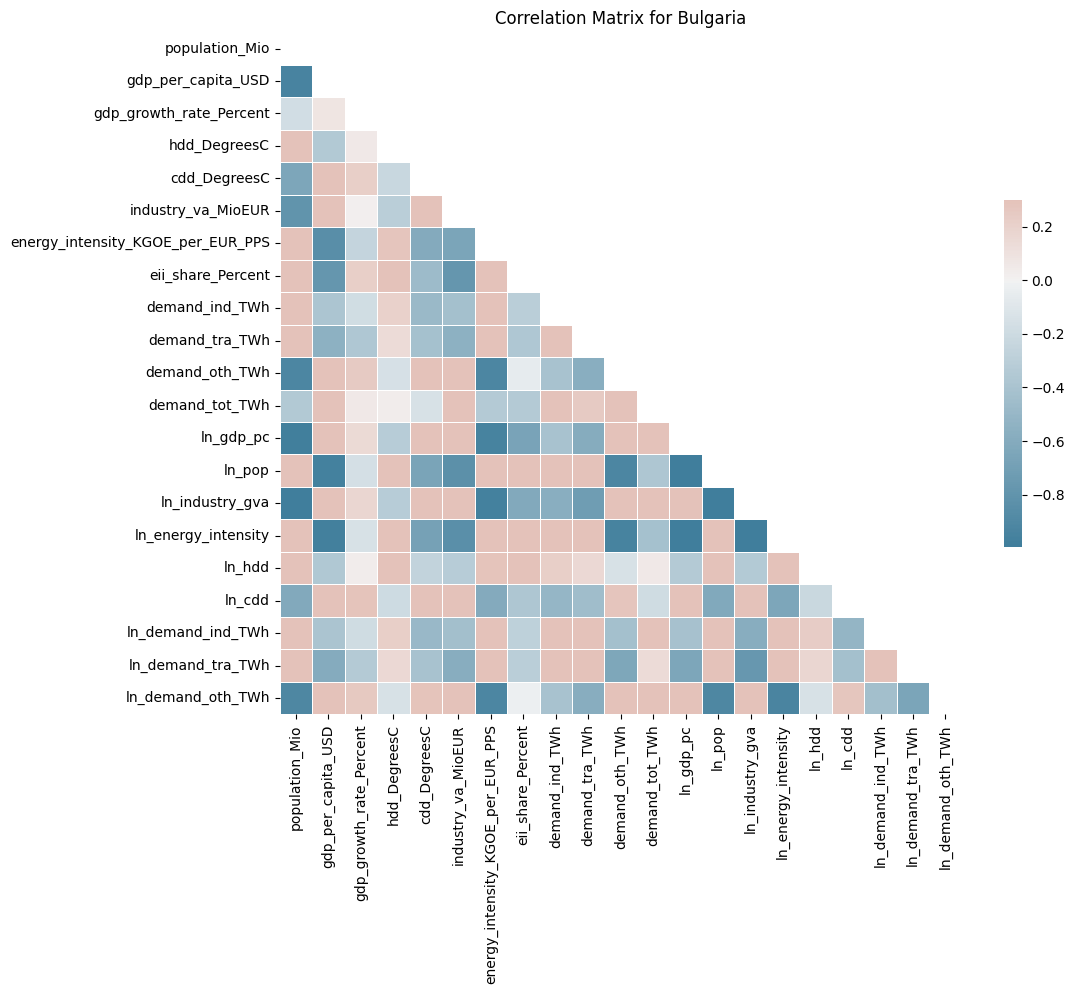

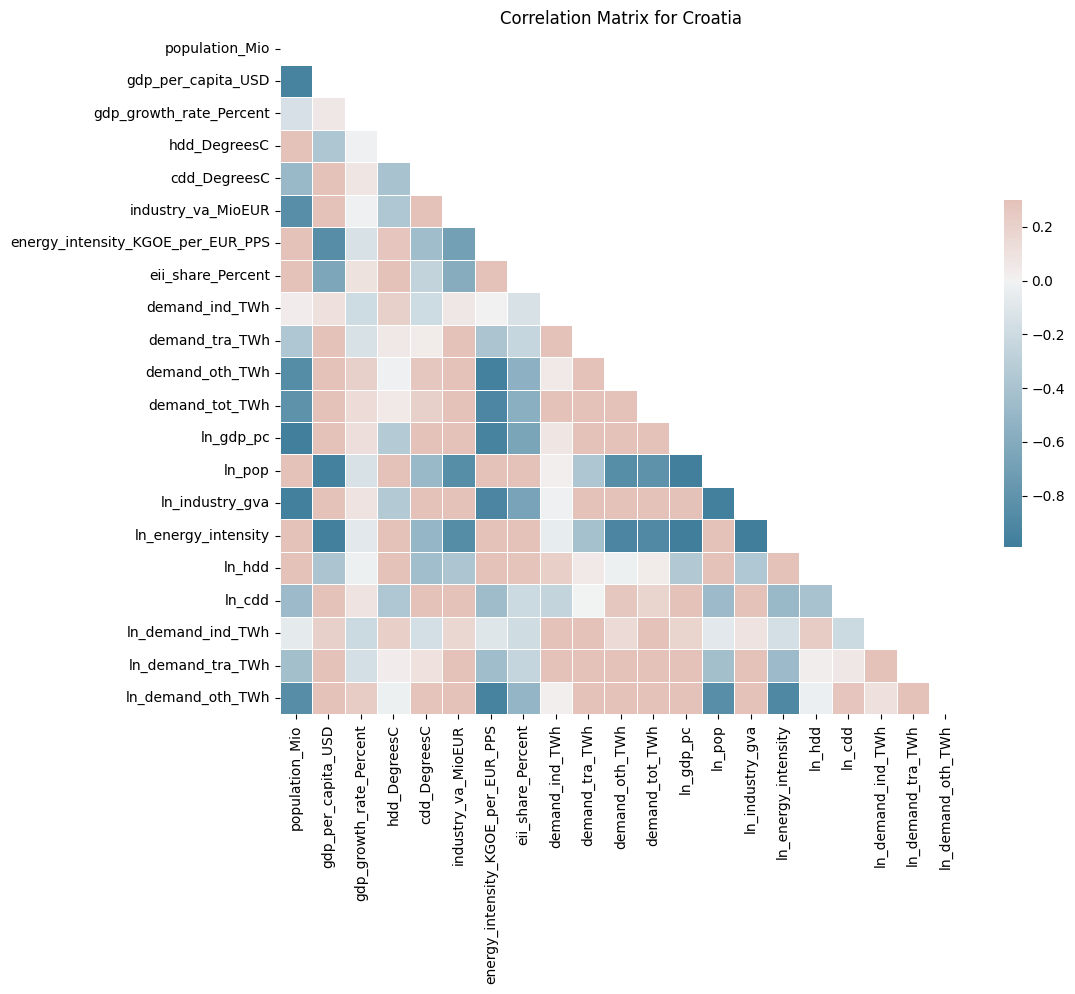

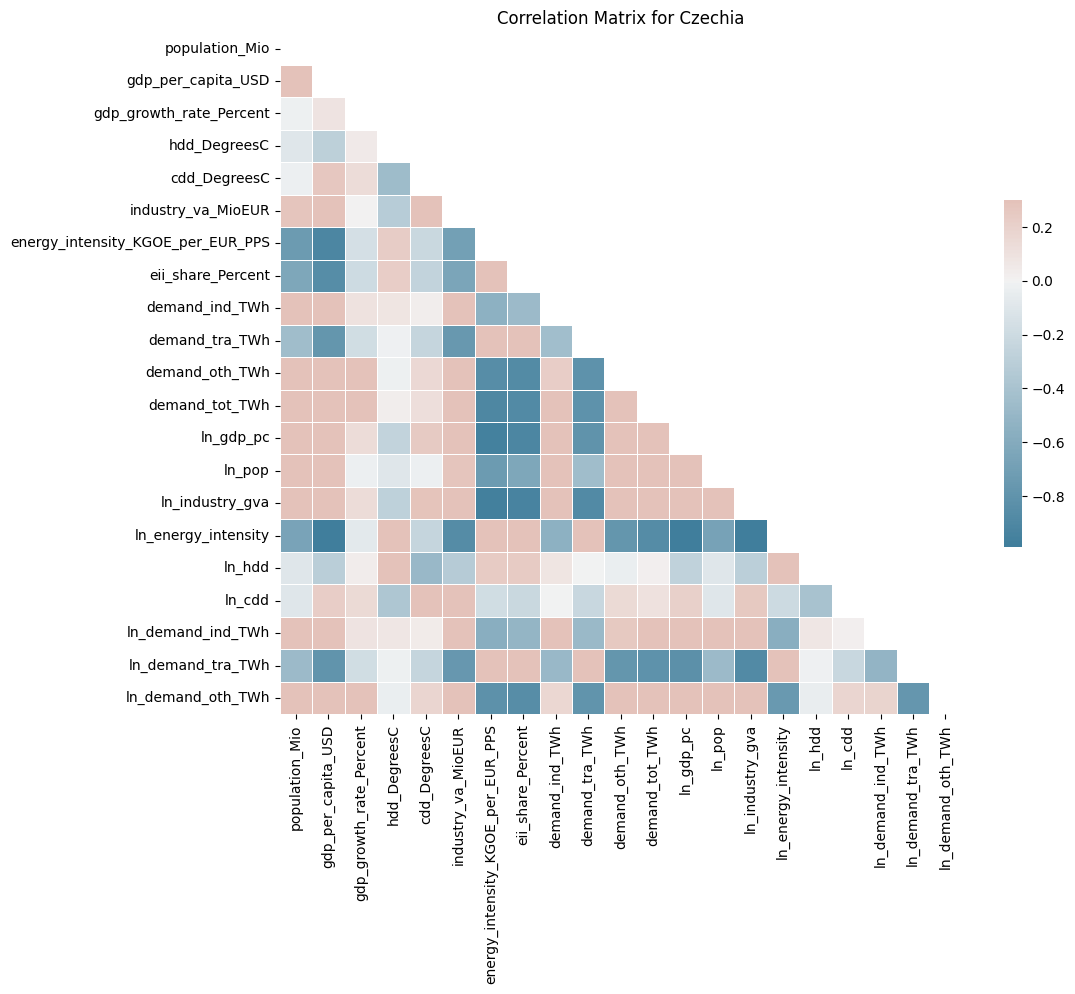

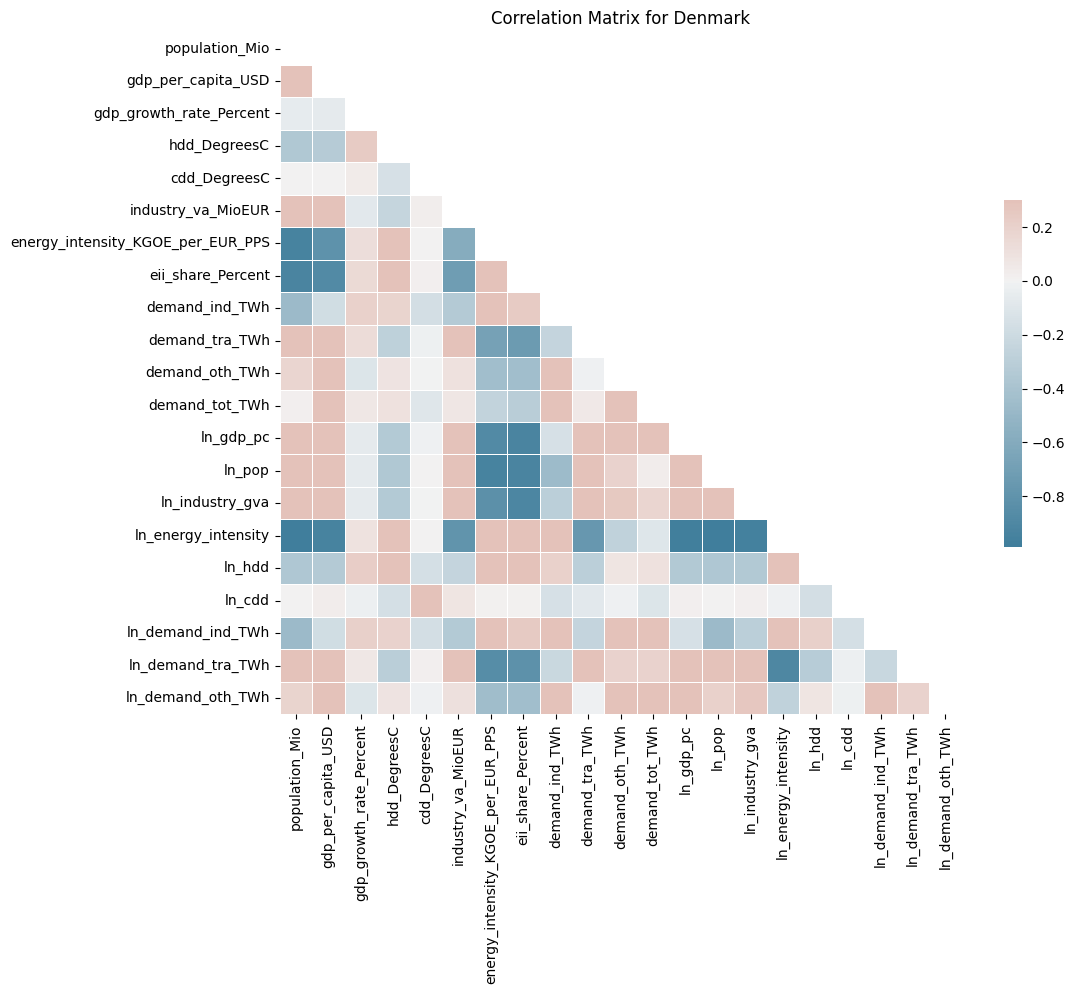

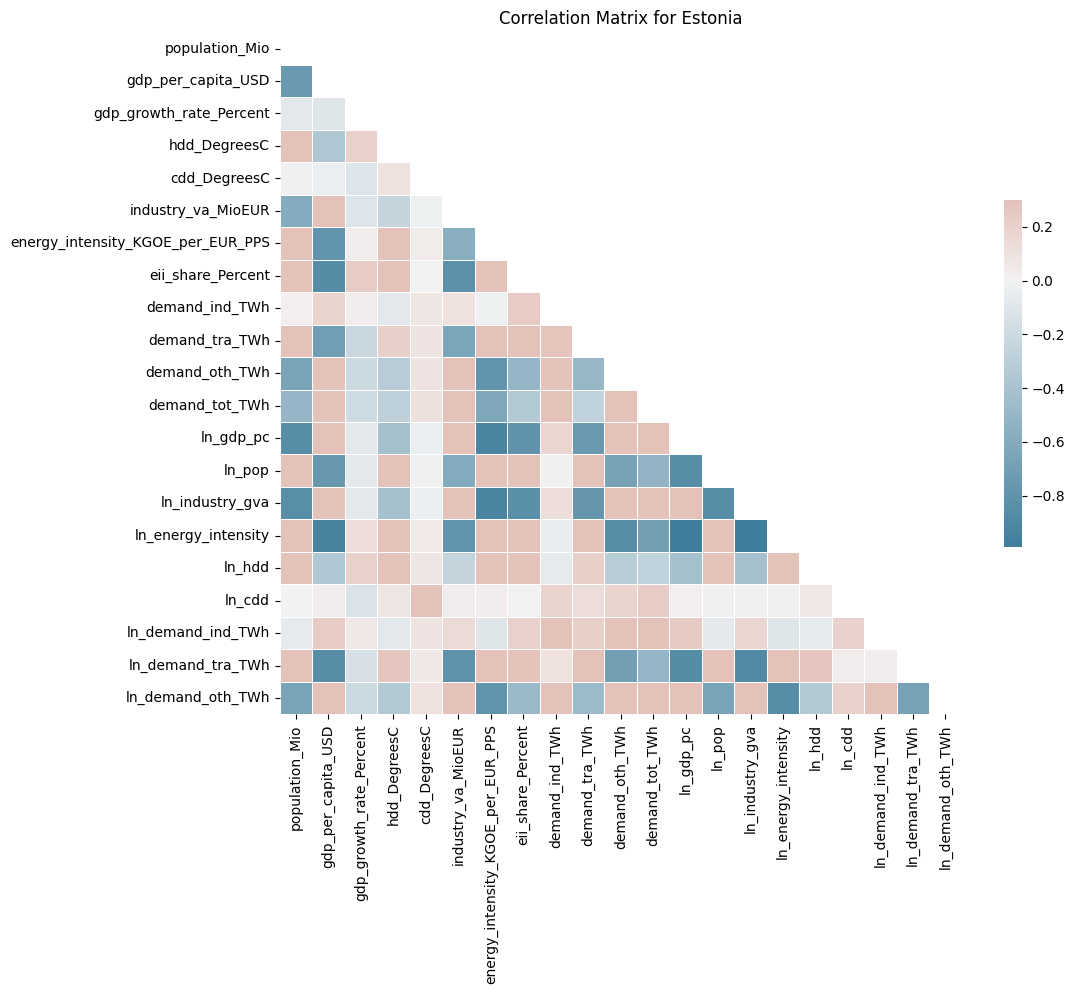

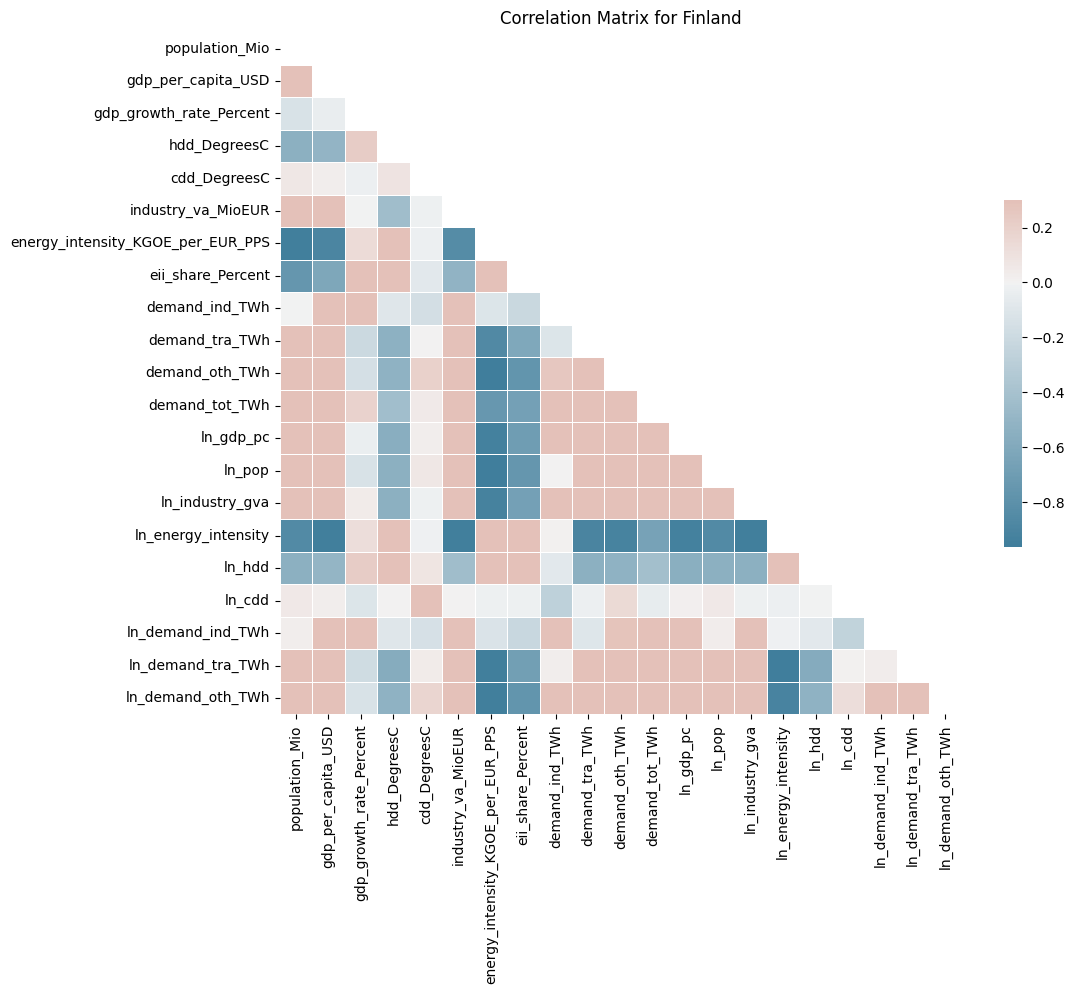

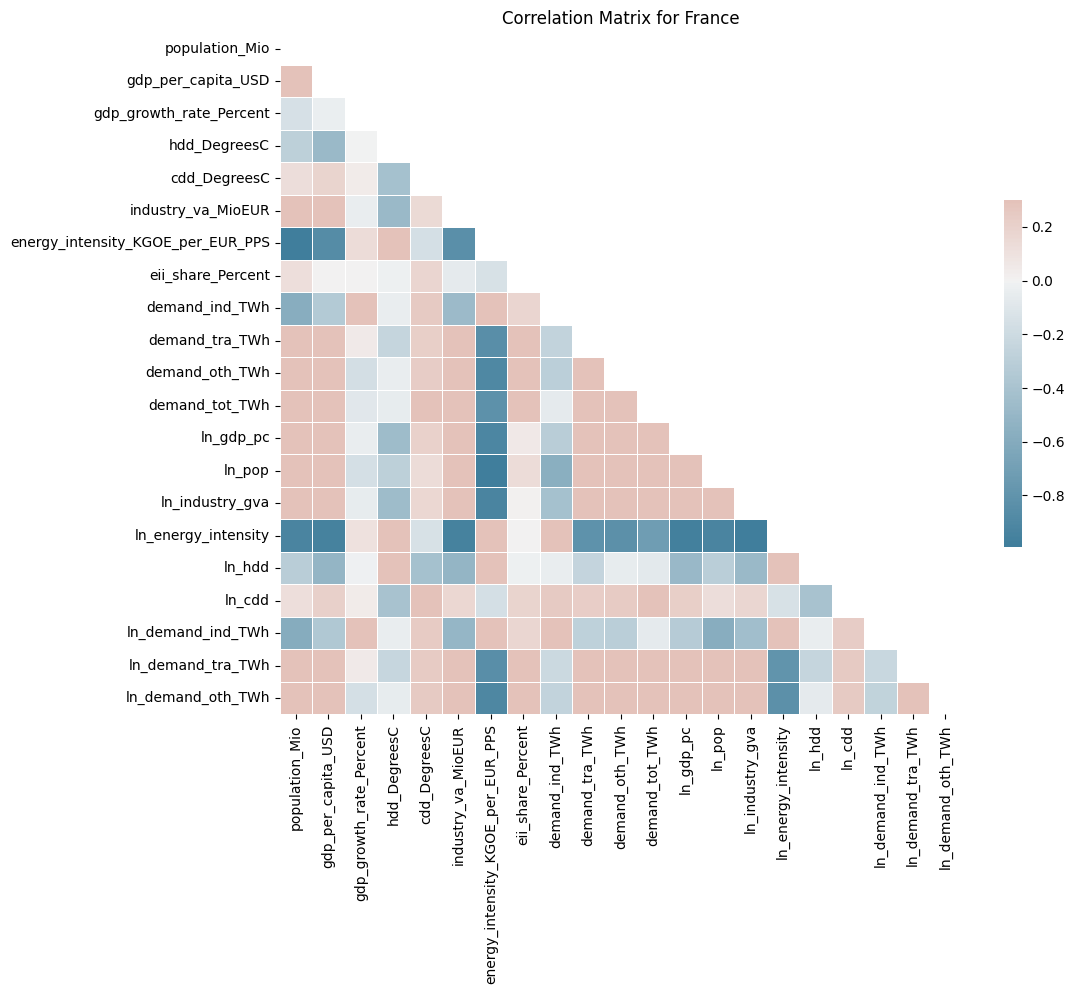

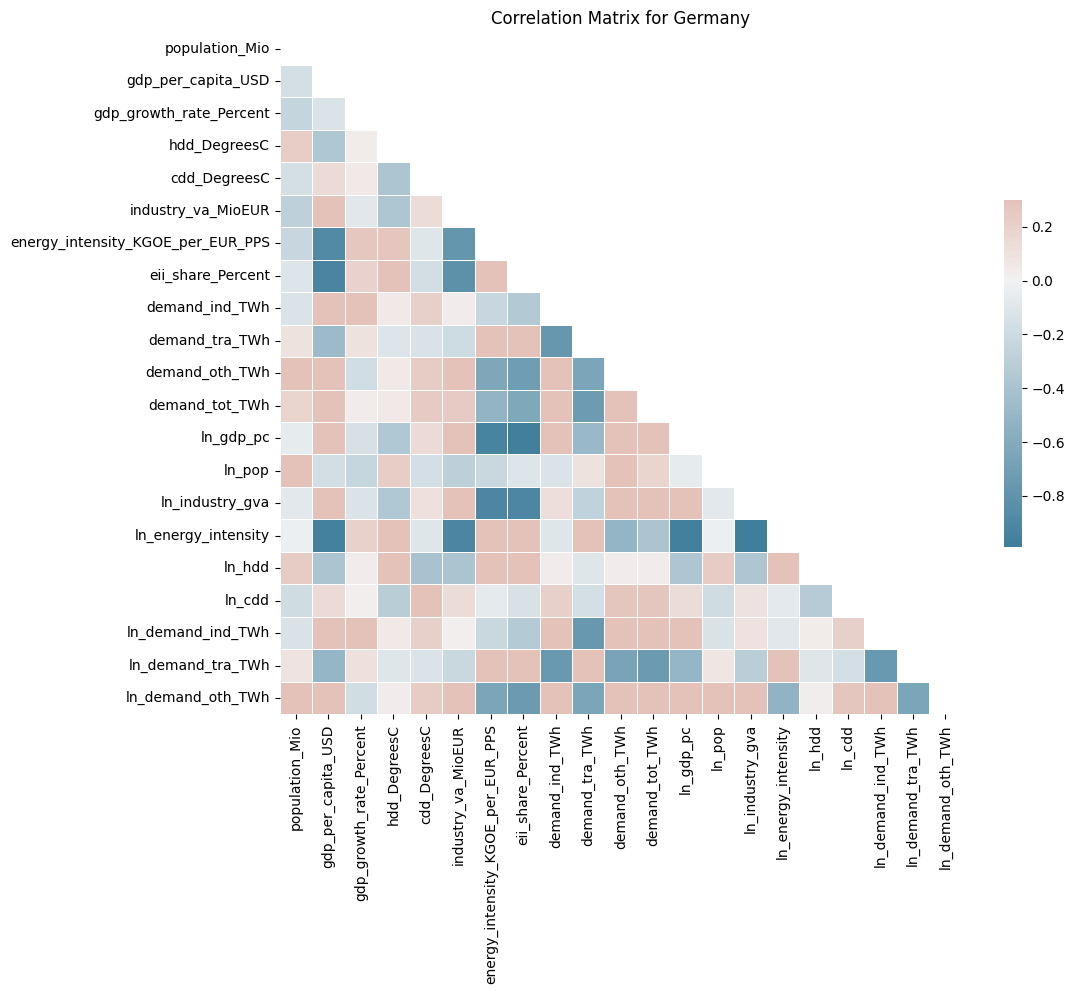

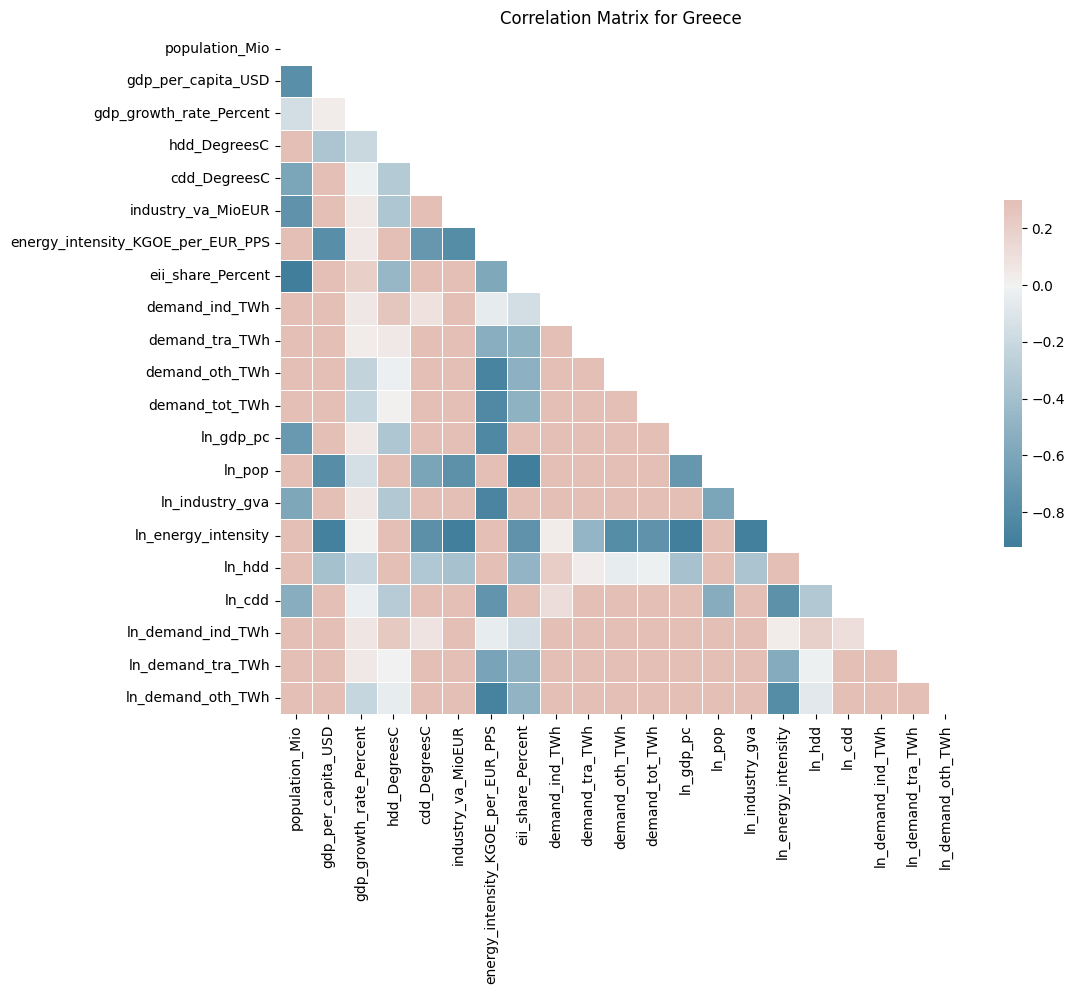

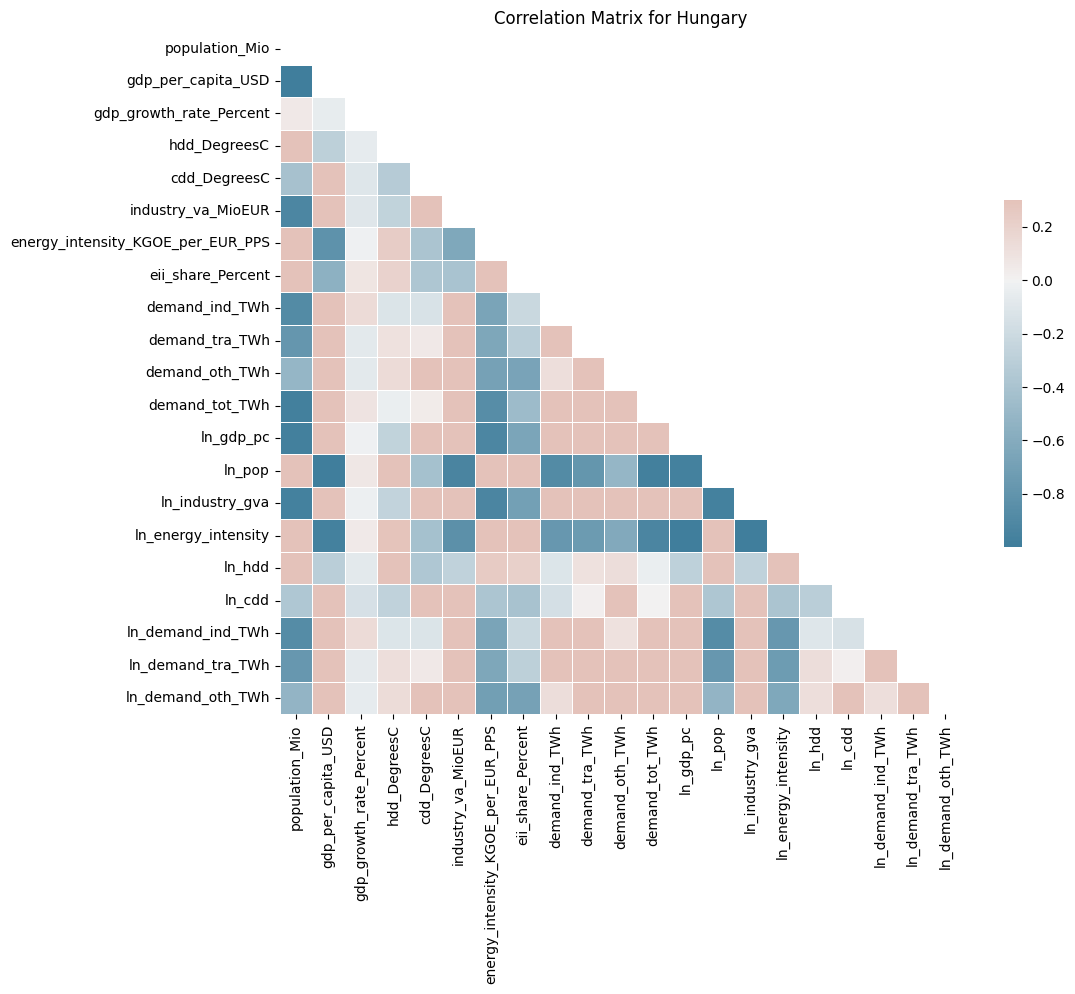

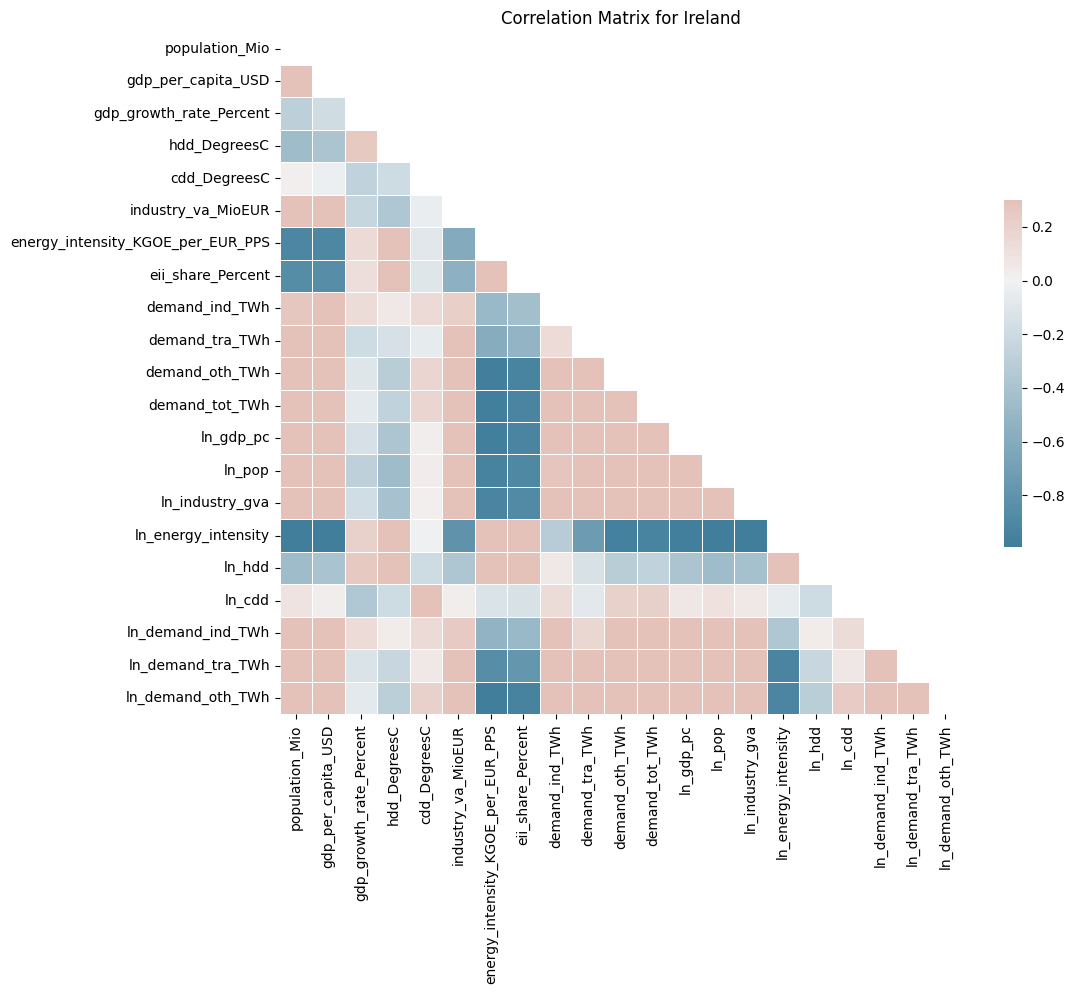

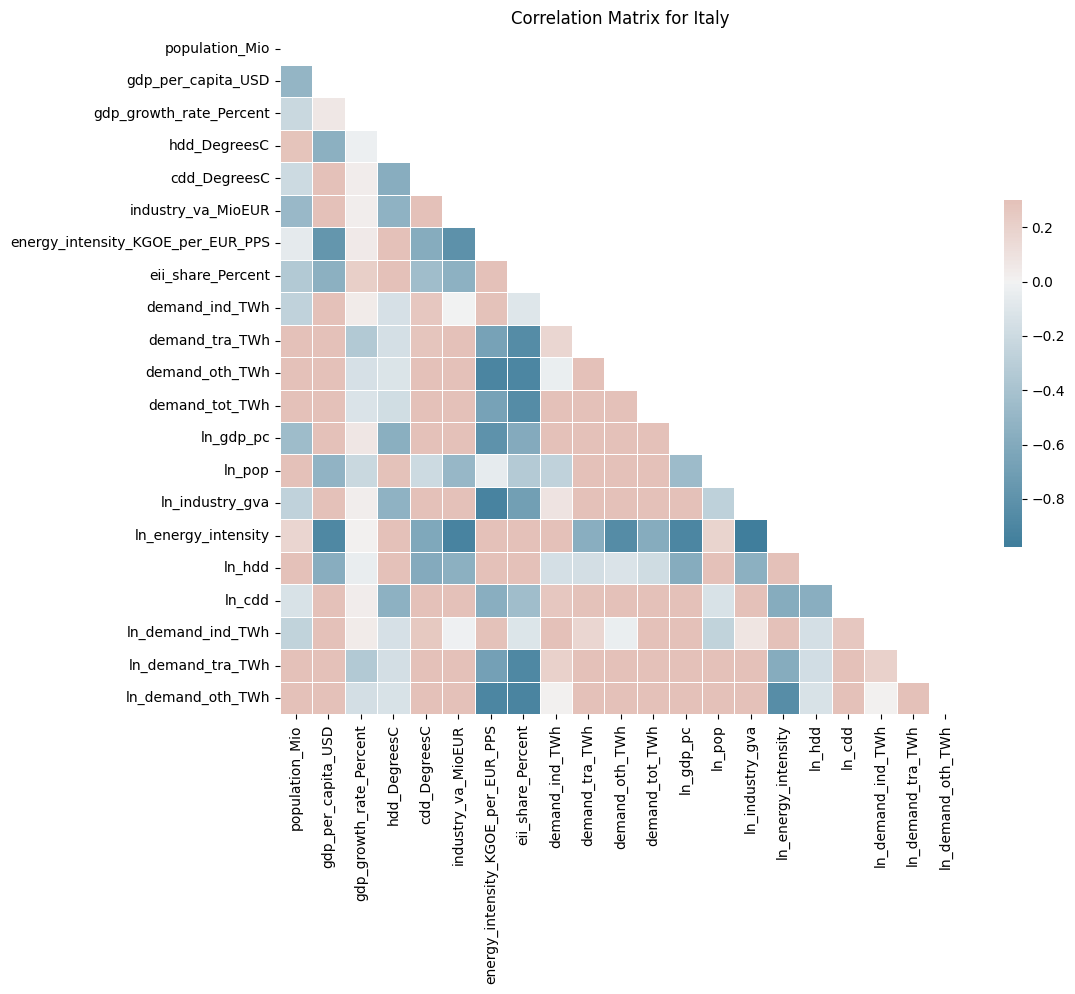

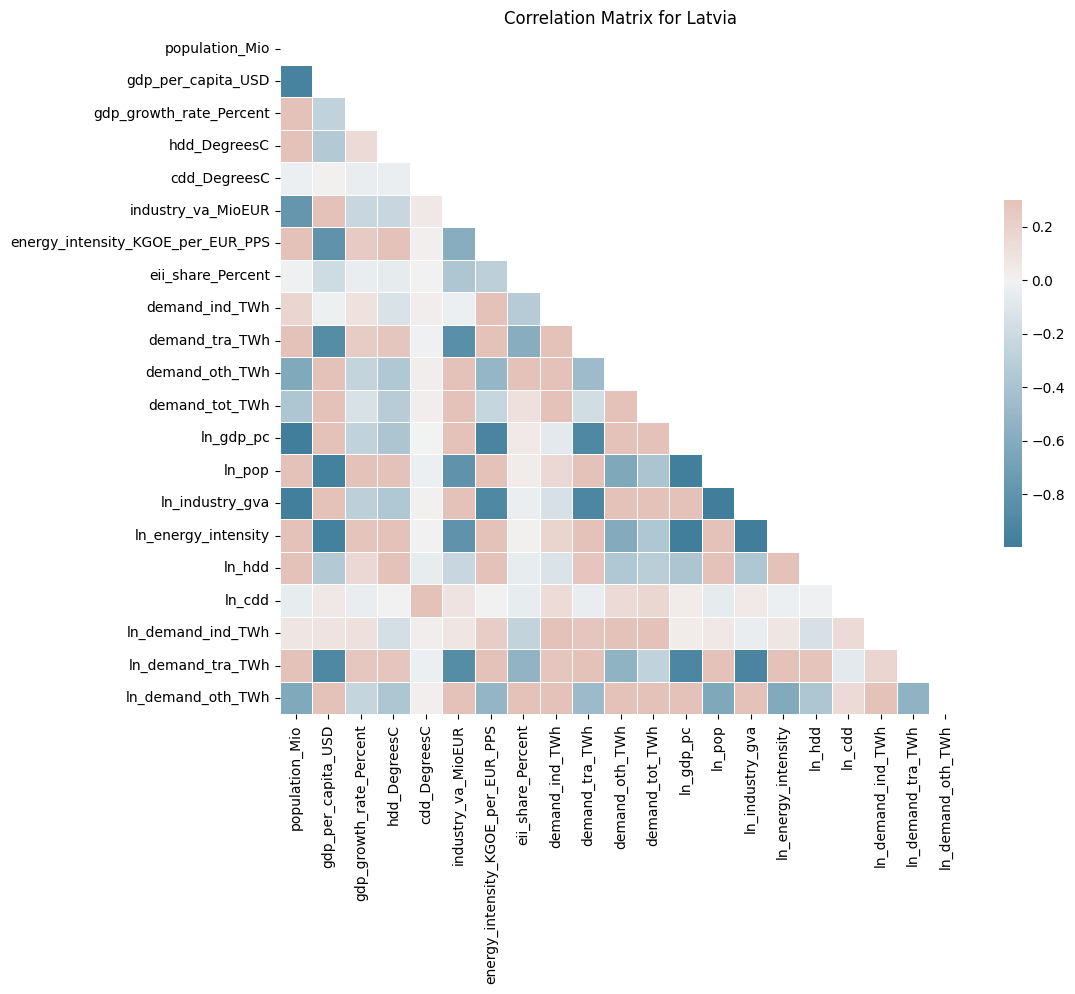

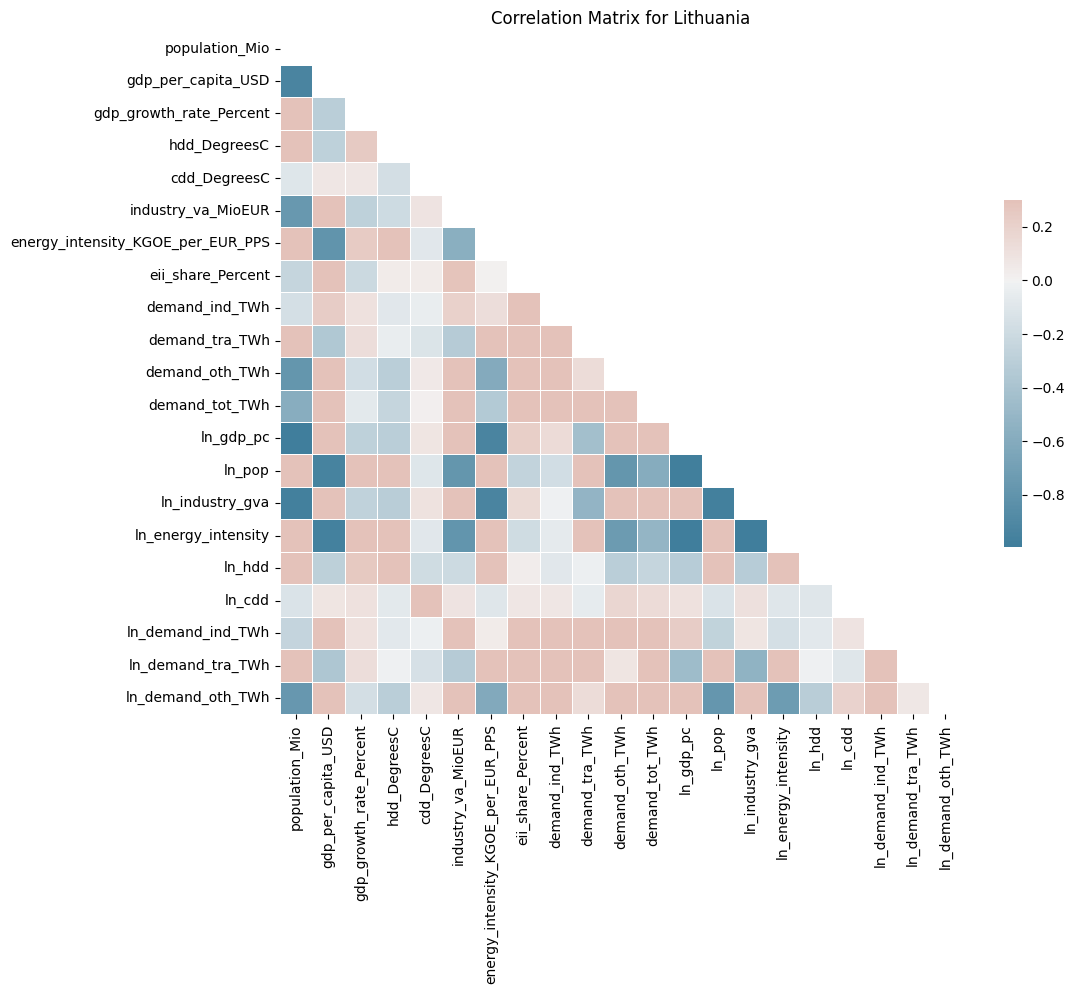

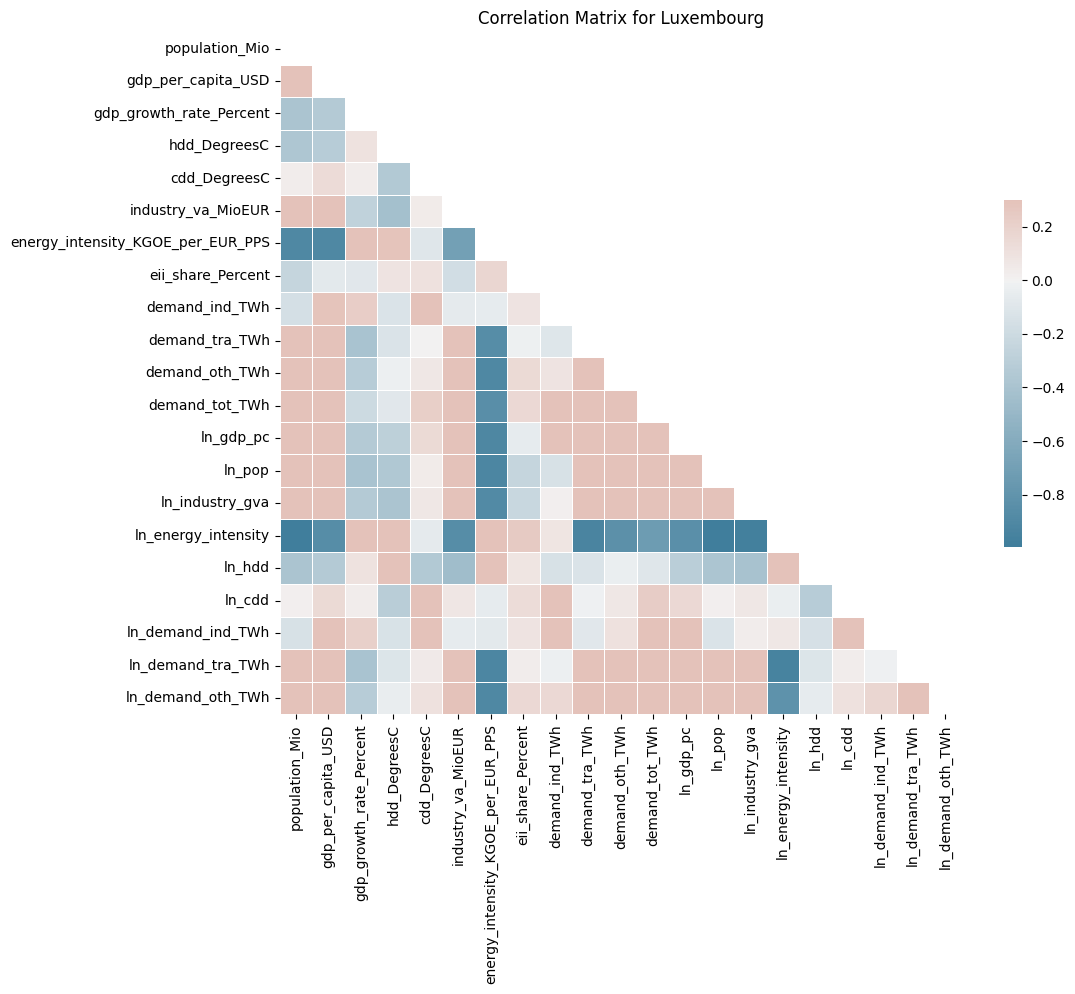

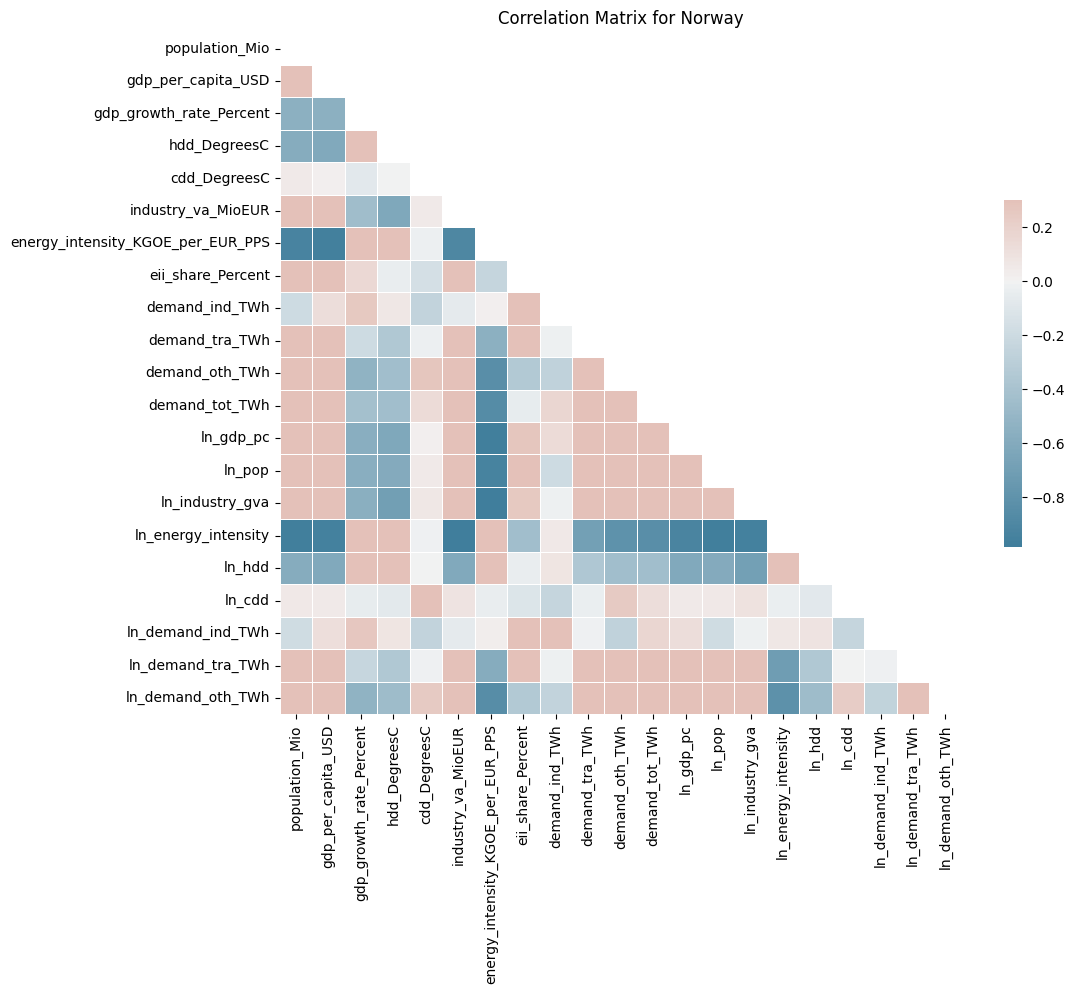

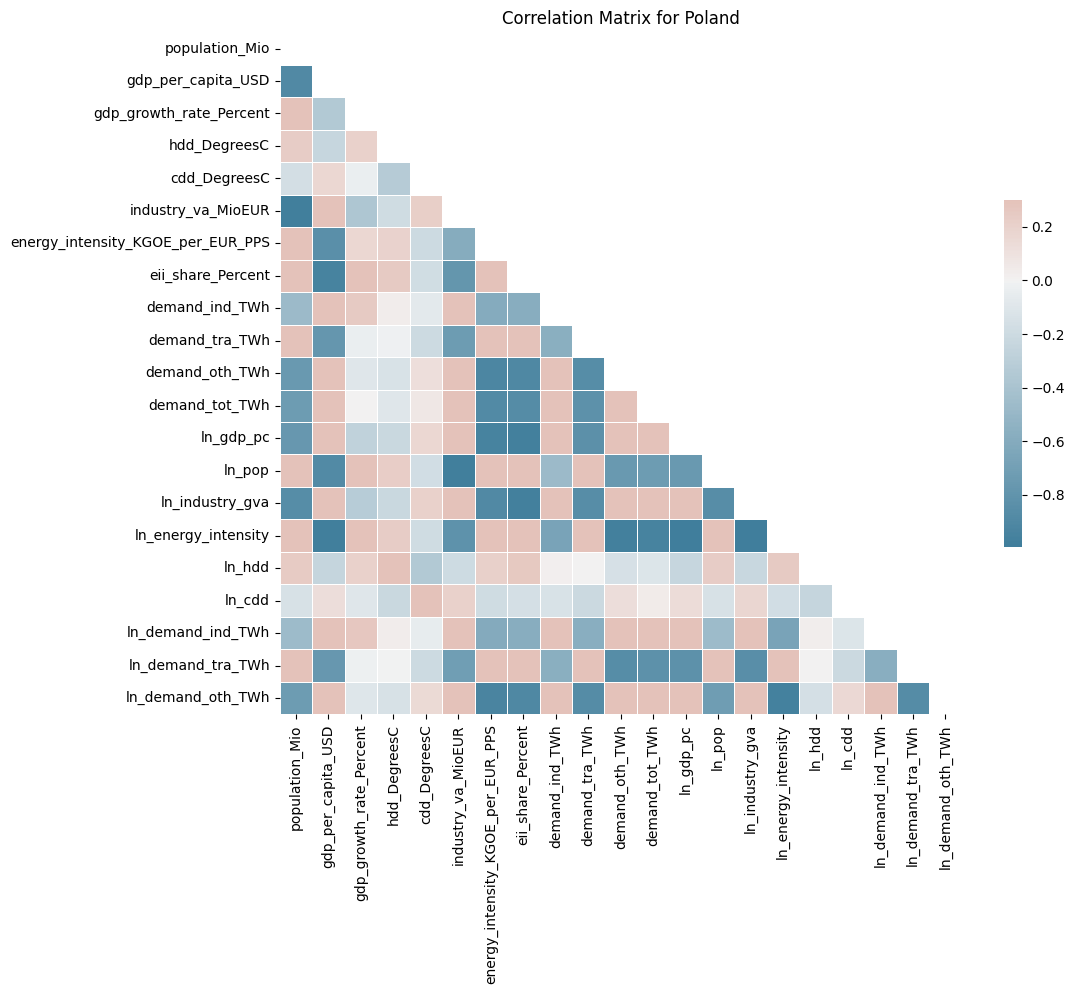

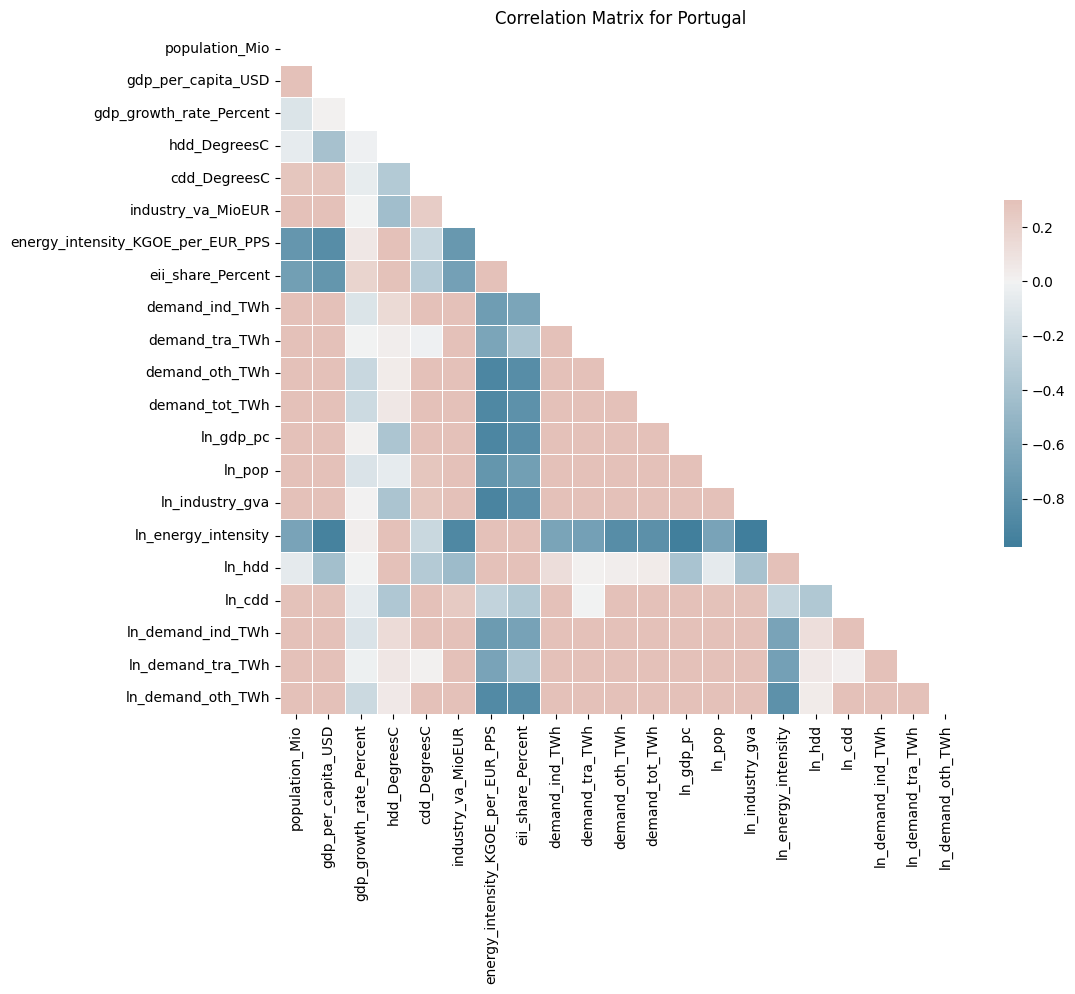

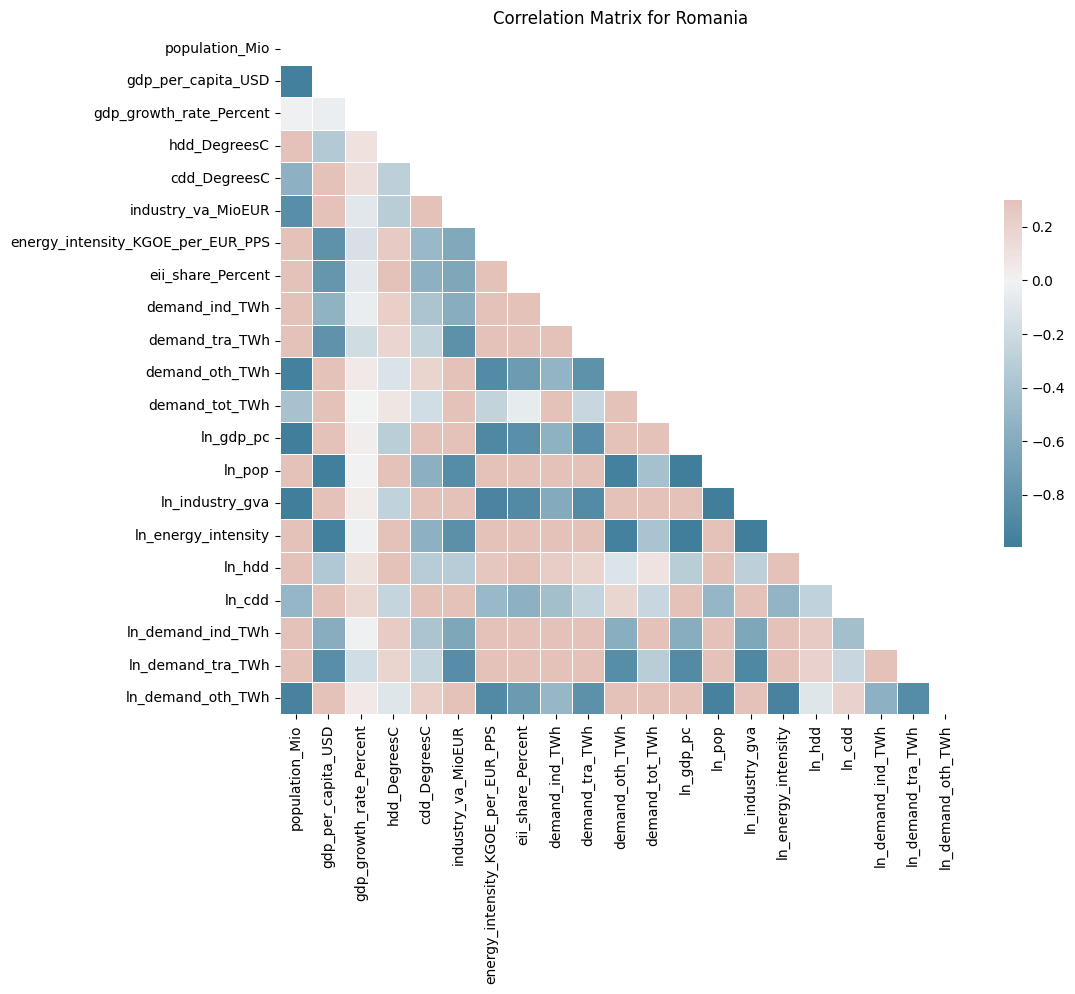

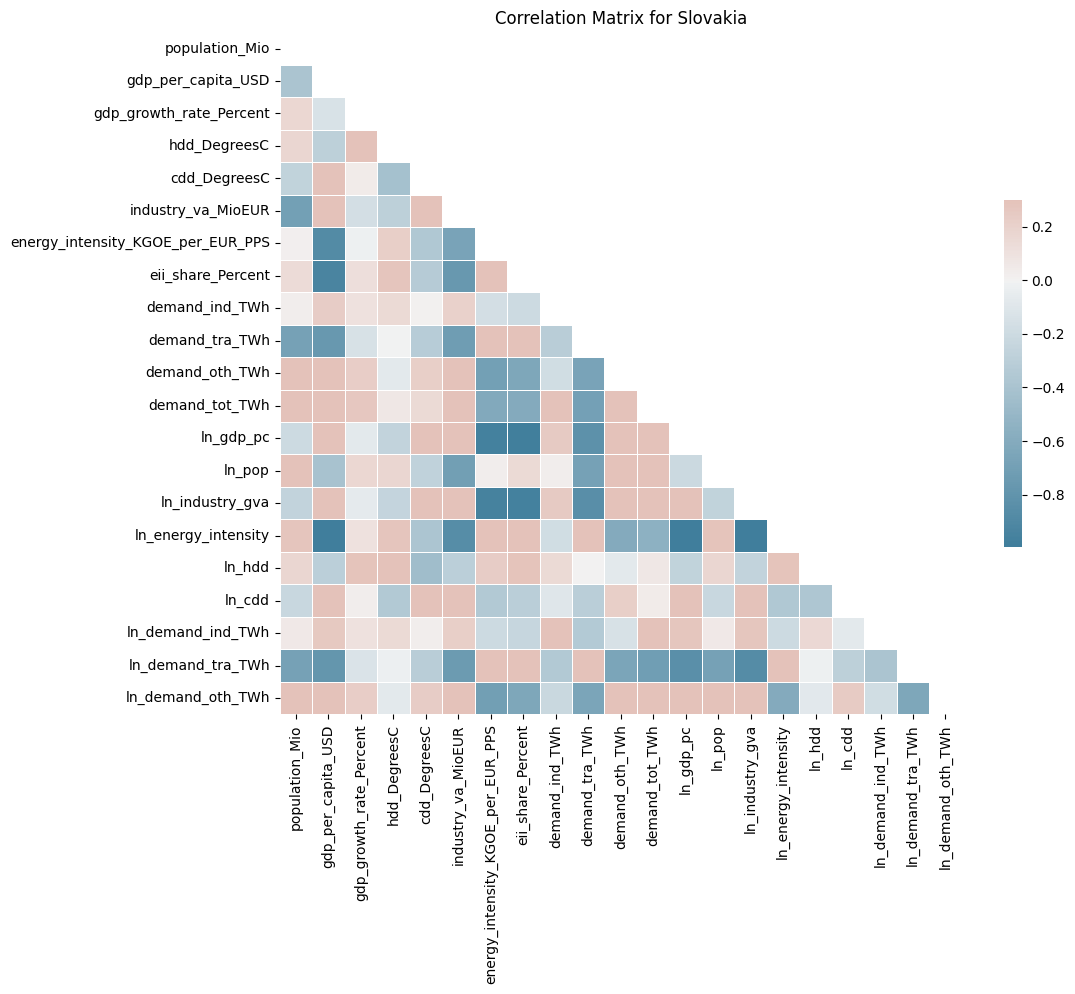

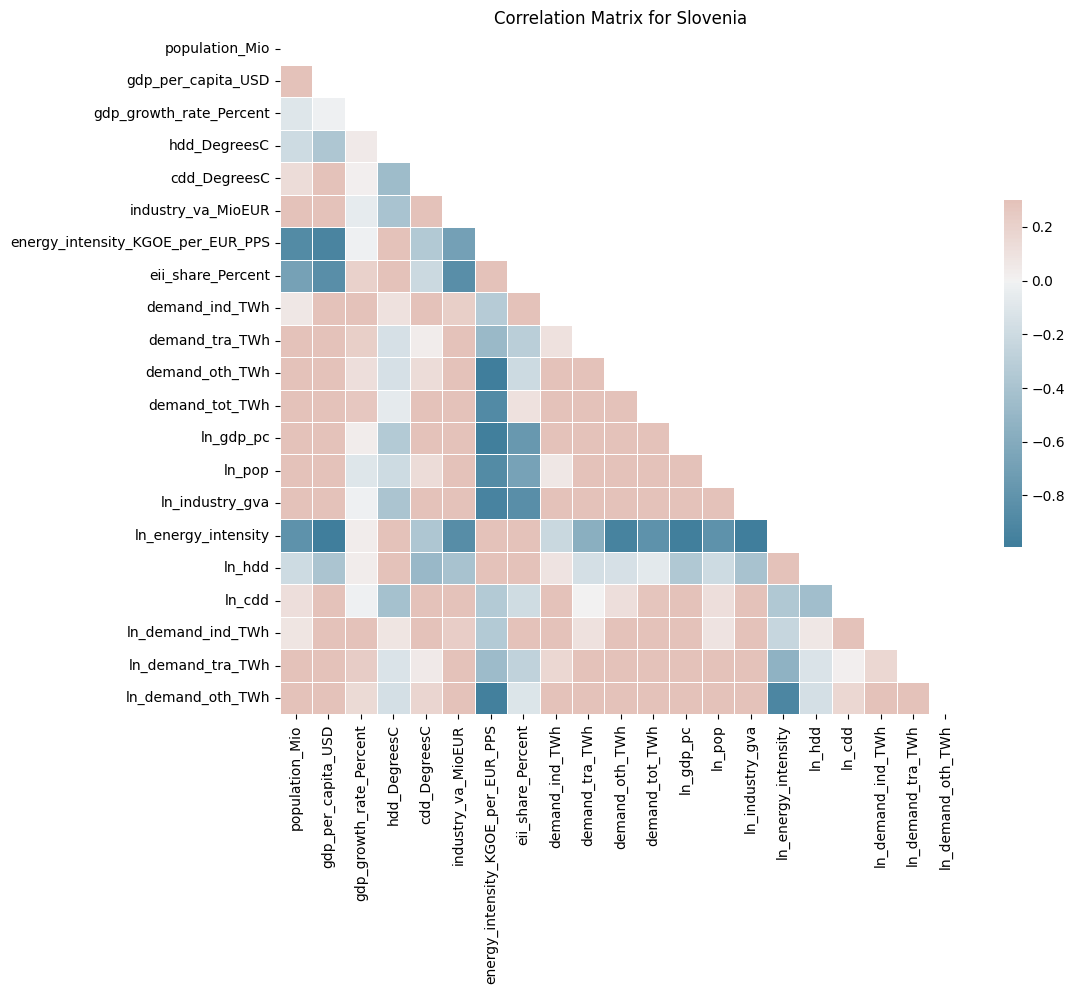

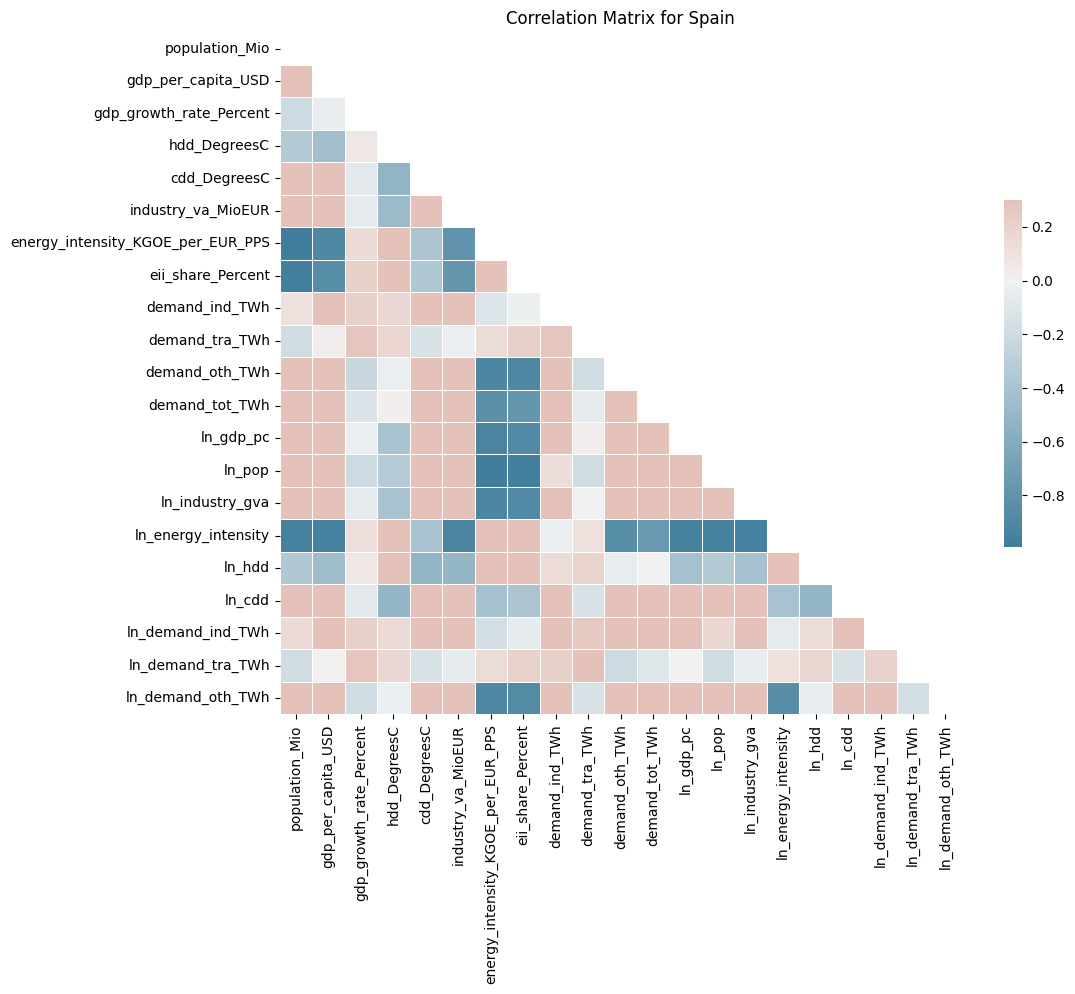

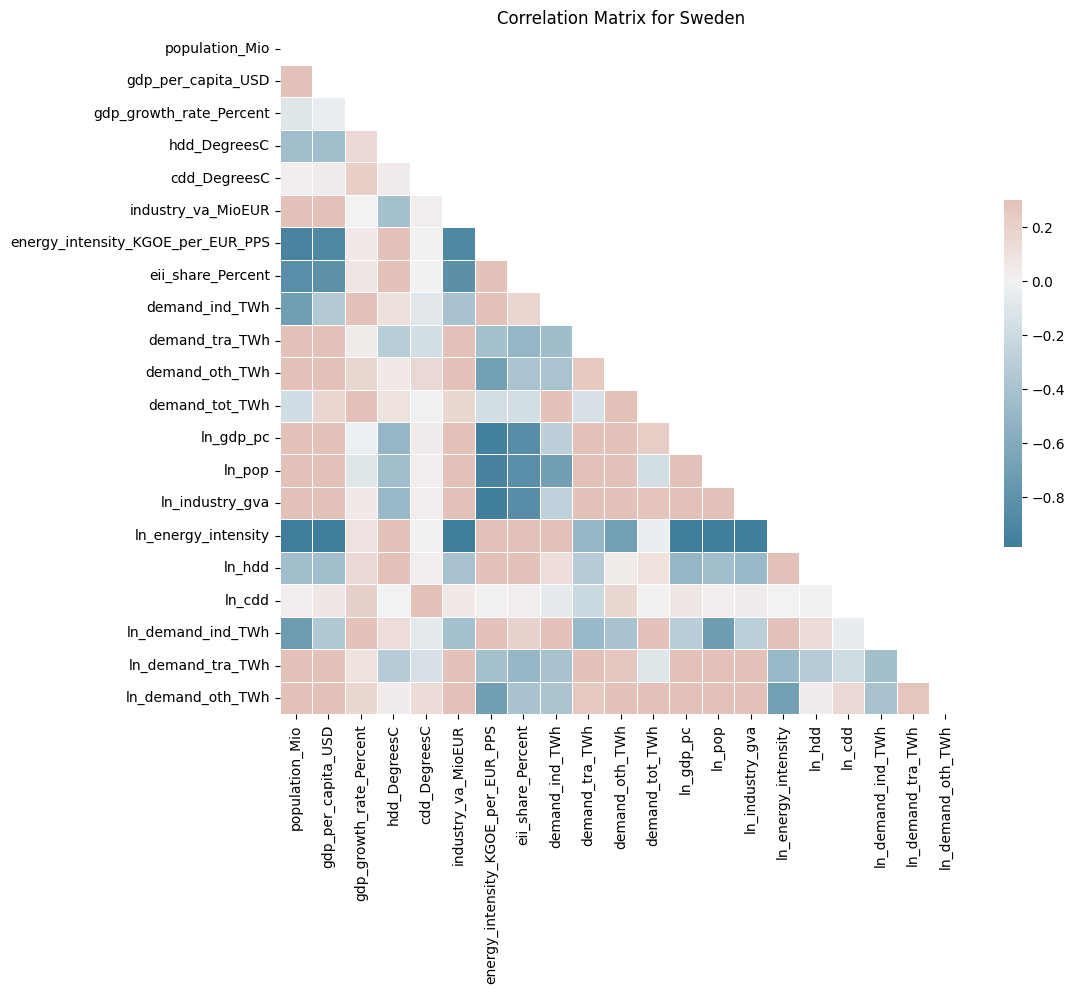

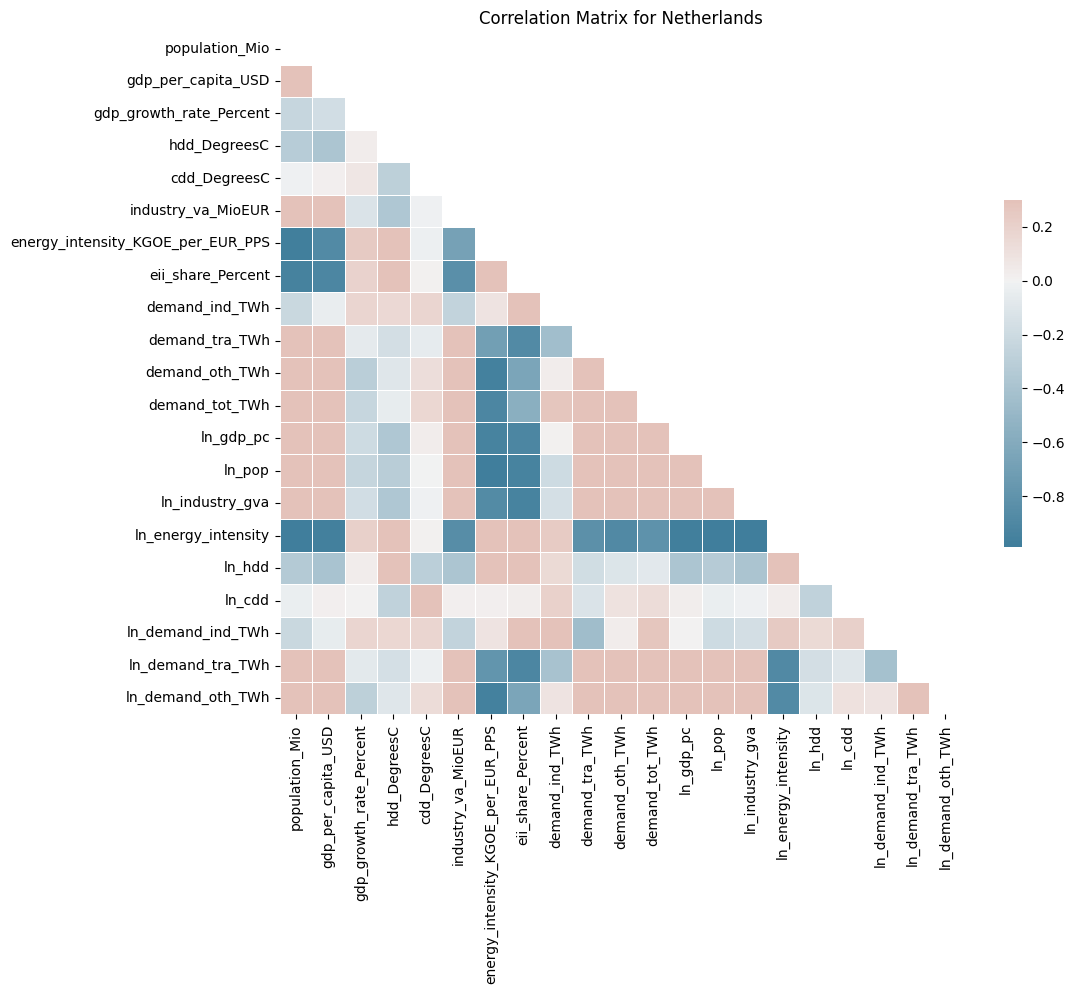

In [ ]:
"""for COUNTRY in countries:
    if COUNTRY == "Germany including former GDR":
        continue
    
    corr_by_country = panel.groupby(level='country').corr()
    corr = corr_by_country.loc[COUNTRY]

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})

    ax.set_title(f"Correlation Matrix for {COUNTRY}")

    plt.savefig(f"Results/Correlation Matrix/Correlation Matrix for {COUNTRY}.png", dpi=300, bbox_inches="tight")"""

In [47]:
panel.describe().T

,count,mean,std,min,25%,50%,75%,max
population_Mio,1222.0,17.031487,21.458883,0.379300,4.528852,8.883214,16.711711,8.357714e+01
gdp_per_capita_USD,1222.0,51241.083856,26772.621078,10705.534650,33168.993235,47127.784585,62112.733918,1.728837e+05
gdp_growth_rate_Percent,1222.0,2.131099,3.212013,-15.767713,1.076239,2.041083,3.489626,2.225224e+01
hdd_DegreesC,1222.0,2679.577382,1009.537697,718.471058,2033.305993,2556.195691,3225.021920,5.523473e+03
cdd_DegreesC,1222.0,104.224807,109.185834,0.000000,19.876377,57.533914,170.949083,5.835635e+02
industry_va_MioEUR,1222.0,234878.693754,442584.670604,1038.642286,24971.229588,83863.500000,211318.415622,5.466949e+06
energy_intensity_KGOE_per_EUR_PPS,1222.0,164.458891,121.677912,10.331476,79.697116,135.550000,211.282500,9.478910e+02
eii_share_Percent,1222.0,15.637646,6.383602,0.403105,11.876440,15.299416,19.568487,3.501401e+01
demand_ind_TWh,910.0,37.016693,49.092035,1.325000,6.807826,17.791000,43.967250,2.393070e+02
demand_tra_TWh,910.0,2.318216,3.461877,0.016000,0.222500,0.807000,2.865750,1.748800e+01
